# 10. Securing Our API - B

##### 10.01.1.0. Skimming: What did you notice and why? Any Questions

_**What?**_  
Currently the `/newsletters` endpoint accepts a newsletter issue as JSON and then sends emails out to all subscribers.  

_**Why?**_  
Only priviledged uses should be able to publish a newsletter (create a newsletter issue) and send it out to subscribers.  
Right now anyone can hit the endpoint and broadcast whatever they want to our existing mailing list.

_**Questions?**_  
What is the best way to breakdown this chapter because it is quite a bulky one?  

While perusing the bulkiest sections are
- Password-based Authentication
- Login
- Sessions + Seed Users

So a session needs to ensure that we have enough context to clear a section without information overload.

## 10.06. Login. (_bulky_)

##### 10.06.0.0. Skimming: What did you notice and why? Any Questions

_**What?**_
- `login_form` which is a handler for `GET /login` and `login` which is a hander for`POST /login`.  
  They are defined in separate `src/routes/login/get.rs` and `src/routes/login/post.rs` modules
- [MDN Web Docs](https://developer.mozilla.org/en-US/docs/Web/HTTP/Guides/Redirections) on `3xx` redirects
- Adding an `AuthError` enum that we now use on `validate_credentials` as opposed to `PublishError`.
- Passing error information from `login` to `login_form` handers via HTML hard coded in the `login_form` handler
- `htmlescape` crate that helps us prevent XSS attacts (Cross-Site-Scripting Attacks)
- HMAC (**H**ash-based **M**essage **A**uthentication **C**odes): Keyed-Hasing for Message Authentication
  [RFC2104](https://datatracker.ietf.org/doc/html/rfc2104)
- `actix_web::error::InternalError` that we use with `LoginError` i.e `InternalError<LoginError>`
- Repository [snapshot](https://github.com/LukeMathWalker/zero-to-production/tree/root-chapter-10-part1) at the end of section _10.6.4.7 - Error Messages Must Be Ephemeral_
- Flash messages using cookies
- Finally adding `/login` tests when about to set error messages
- `post_login` adds a trait bound instead `Body: serde::Serialize` instead of using just a plain `body: serde_json:Value`
- Updating our `TestApp` struct to include `api_client: reqwest::Client` and refactoring all our calls to `reqwest::Client` to use `self.api_client` instead
- We update our `login_form` handler to use the `HttpReques` itself to retrieve the cookie instead of using the `Query` extractor with `QueryParams` struct we defined.
- `add_removal_cookie` method that automatically sets `_flash` cookie `MAX-AGE=0` behind the scenes.
- `actix-web-flash-messages` for setting, passing, and revoming cookie flash messages.
- Went into a rabbit hole and explored [axum-login](https://github.com/maxcountryman/axum-login)

_**Why?**_
- Was wondering why our login module had both a `get.rs` and `post.rs`. Now I understand.
- Interesting supplimentary material
- We to a `match` to convert an `AuthError` into a `PublishError`. Curious we could get a clean conversion using `#[source AuthError]` instead.
- This would be the place to explore `askama` or `tera` crate.
- First actix specific addition that we'll have to map to the axum equivalent
- Cool that the author acknowledges that the chapter is long.
- Looking forward to learning about cookies.
- Was thinking how one would go about testing the `/login` handlers if we didn't end up testing the implementation.
- We are introduced to another way of implementing a test helper.
- How we are able to persist the cookie store when using the `reqwest::Client` for client side interactions.
- `HttpRequest` allows us to access the cookie store.
- Like the pattern the chapter has followed around being explicit around the implementation and then showing the abstraction.
- Since we are using `actix-web-flash-messages` is there an axum equivalent.

_**Question?**_
- What is the axum equivalent of `actix_web::error::InternalError`?
- What is the axum equivalent of `actix-web-flash-messages`
  > Seems the choice is between
  > - [axum-flash](https://github.com/davidpdrsn/axum-flash) light weight
  > - [axum-messages](https://github.com/maxcountryman/axum-messages) full-fledged built ontop of tower sessions, modeled
  >   closely after Django Messages similar to `actix-web-flash-messages`.  
  >   Seems like the best drop in axum alternative for `actix-web-flash-messages
- Curious where to draw the line when it comes cookies, sessions, authorization/authentication between front end and purely API backends.
  > [Claude](https://claude.ai/chat/d40b81b5-4367-4ce2-aa32-0704572e87a6) chat where we explore this for a bit.

##### 10.06.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  

In this section we primarily go through 
- serving the login form html
- redirecting appropriately when the login form data is submitted
- processing the login html form & adding an authentication module that will assist in doing this
- providing feedback to users incase of issues encountered while logging in.

### 10.06.0. Overview

##### 10.06.0.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  

Here we add a `src/routes/login` module with `mod.rs`, `get.rs`, `post.rs` and `login.html`.  
We then stub the up appropriately then wire them up to `src/routes/mod.rs` and `startup.rs`

Let start by adding initial contents of `login.html`, `get.rs`, `post.rs`and `mod.rs`.

```HTML
<!--src/routes/login/login.html-->
 <!DOCTYPE html>
<html lang="en">
  <head>
    <meta http-equiv="content-type" content-type="text/html" charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <link rel="icon" href="data:,">
    <title>Login</title>
  </head>
  <body>
    <form>
      <label>
        <input 
          type="text"
          placeholder="Enter Username"
          name="username">
      </label>
      <label>
        <input 
          type="password"
          placeholder="Enter Password"
          name="password">
      </label>
      <button type="submit">Login</button>
    </form>
  </body>
</html>
```

```Rust
//! src/outes/login/get.rs
use actix_web::{HttpResponse, http::header::ContentType};

pub async fn login_form() -> HttpResponse {
    HttpResponse::Ok()
        .content_type(ContentType::html())
        .body(include_str!("./login.html"))
}
```

The above is similar to what we did before when serving the `home.html` via the `home` handler in `src/routes/home/mod.rs`.  
Lets wire this up and this to `startup.rs`'s `.route`.

```Rust
//! src/routes/login/mod.rs
mod get;

pub use get::login_form;
```

```Rust
//! src/routes/mod.rs
// [...]
mod login;
// [...]

// [...]
pub use login::*;
// [...]
```

```Rust
//! src/startup.rs
use crate::route::{/**/, login_form};
// [...]

// [...]

fn run(/**/) -> Result<Server, std::io::Error> {
    // [...]
    let server = HttpServer::new(move || {
        App::new()
            // [...]
            .route("/login", web::get().to(login_form))
            // [...]
    });
    // [...]
}
```

Lets compile this and run this and look at what we have at `/login`

### 10.06.1. HTML Forms

![image.png](10_b_securing_our_api_files/c44ca008-d37b-45a3-b50d-2825a4fae4f4.png)

![image.png](10_b_securing_our_api_files/30485ade-7f92-4bb2-a34e-1f5bb40d7b6e.png)

The default `form` is to submit the data to the very same page it is being served from (i.e `/login`) using the `GET` verb. This is far from idea because as we can see forms we submit via `GET`  
encodes our input data in clear text as query parameters. Because query parameters are part of the URL they end up being part of the navigation history and are also captured by the logs

![image.png](10_b_securing_our_api_files/0fd92a70-3f43-42b5-864d-e754b1b14fc5.png)

To change this behavior we add `method` and `action` attribute to the `form` element as follows

```HTML
<!--src/routes/login/login.html-->
<!--[...]-->
    <form method="POST" action="/login">
<!--[...]-->
```

By adding `method="POST"` the input data becomes part of the request body posted to the `/login` endpoint, which is a much safer option.

![image.png](10_b_securing_our_api_files/1a108c99-567e-4ff5-9420-3f61d5b4f37c.png)

Our request now looks like the above image. We are getting `404 NOT FOUND` because we have not yet added a post `login` handler. Lets do so and define the endpoint.

### 10.06.2. Redirect On Success

```Rust
//! src/outes/login/login.rs
use actix_web::{HttpResponse, http::header::LOCATION};

pub async fn login() -> HttpResponse {
    HttpResponse::SeeOther()
        .insert_header((LOCATION, "/home"))
        .finish()
}
```

In this `login` handler we introduce `SeeOther` with is a [`303`](https://developer.mozilla.org/en-US/docs/Web/HTTP/Reference/Status/303) redirect which is the most fitting  
redirect for our usecase, because after a successful login, we want to redirect users to the `home` page. 
> [MDN Web Docs](https://developer.mozilla.org/en-US/docs/Web/HTTP/Guides/Redirections) provides a comprehensive guide on `3xx` range redirect status codes.

Lets wire this up
```Rust
//! src/routes/login/mod.rs

mod get;
mod login;

use get::login_form;
use post::login;
```

```Rust
//! src/startup.rs
use crate::route::{/**/, login};
// [...]

// [...]

fn run(/**/) -> Result<Server, std::io::Error> {
    // [...]
    let server = HttpServer::new(move || {
        App::new()
            // [...]
            .route("/login", web::post().to(login))
            // [...]
    });
    // [...]
}
```

The code should compile and now when we submit the form we are greeted with `"Welcome to our newsletter"` as shown below

![20260710-0740-55.0795612.gif](10_b_securing_our_api_files/36c43df5-6040-4717-abd7-a0b680598222.gif)

### 10.06.3.Processing Form Data

#### 10.06.3.0. Overview

##### 10.06.3.0.1 Deep Dive: Summarize, ELI5, Connect 

_**Summary**_  
Here we primarily review how we can best process the data submitted in the login page.
We will need a `FormData` struct to hold the `username` and `password` and the `Form` extractor provided by `actix_web` to get the submitted values.
```Rust
//! src/routes/login/login.rs
// [...]
use actix_web::web


#[derive(serde::Deserialize)]
struct FormData {
    username: String,
    password: SecretString,
}

pub async fn login(_form: web::Form<FormData>) -> HttpResponse {
    // [...]
}
```

From there we need to be able to validate the credentials. So we will need to make use of the `validate_credentials` However as it is right now 
[`validate_credentials`](https://github.com/SamNgigi/zero_to_production/blob/1e410b8df2855f4a366855fecdb484444711c338/zero2prod/src/routes/newsletters.rs#L141) is the `newsletter.rs` module returning a
`PublishError`   
incase of a failure mode. 

Validating credentials is ideally an authentication/authorization function. This means `validate_credentials` and the associated logic makes much more sense in an `authentication`  
module returning an `AuthErr`. We can then be able to use it across login functionality and else where where we might need to verify credentials.

That's what we do in the next sub-section.

#### 10.06.3.1. Building An `authentication` Module

In this sub-section we will 
1. Add an `authentication` module
2. Add `AuthError` enum for error handling.
3. Refactor and move `validate_credentials` and associated login `Credentials` struct, `get_stored_credentials` and `verify_password_hash` functions to
   the auth module
4. Update `publish_newsletter` accordingly.
4. Use `validate_credentials` in `login` handler to validate user credentials from the web form.
    - Add `LoginError` for error handling in the handler.
    - Map errors appropriately and/or redirect accordingly.

Our `authentication.rs` module will basically look like this;
```Rust
//! src/authentication.rs
use anyhow::Context;
use argon2::{Argon2, PasswordHash, PasswordVerifier}
use secrecy::SecretString;
use sqlx::PgPool;
use uuid::Uuid;

#[derive(thiserror::Error)]
pub enum AuthError {
    #[error("Invalid Credentials")]
    InvalidCredentials(#[source] anyhow::Error),
    #[error(transparent)]
    Unexpected(#[from] anyhow::Error)
}

pub struct Credentials {
    username: String,
    password: SecretString,
}

#[tracing::instrument(
    name = "Validate Credentials",
    skip(db_pool, credentials)
)]
pub async fn validate_credentials(
    db_pool: &PgPool,
    credentials: Credentials
) -> Result<Uuid, AuthError> {
    let mut user_id = None;
    let mut expected_password = SecretString::from(
        "$argon2id$v=19$m=19000,t=2,p=1$OqVpaPog6F9sxlWW5VoHkA$4uDo1cl2daKq1ZgmmvtQBfG3wwmI8Nk4i8gHk6pwrYA".to_string()
    );

    if let Some((stored_user_id, stored_expected_password)) = get_stored_credentials(db_pool, &credentials.username).await? {
        user_id = Some(stored_user_id);
        expected_password = stored_expected_password;
    };

    spawn_blocking_with_tracing(|| {
        verify_password_hash(expected_password, credentials.password)
    })
    .await
    .context("Failed to spawn blocking task thread.")
    .map_error(AuthError::Unexpected)??;

    user_id.ok_or_else(|| AuthError::InvalidCredentials(anyhow::anyhow!("Invalid Username.")))

    
}

async fn get_stored_credentials(db_pool: &PgPool, username: &str) -> Result<Option<(Uuid, SecretString)>, anyhow::Error> {
    let row = sqlx::query!(
        r#"
            SELECT user_id, password_hash
                FROM users
            WHERE username = $1
        "#,
        username
    )
    .fetch_optonal(db_pool)
    .await
    .context("Failed to execute query to retreive stored credentials")?
    .map(|r| (r.username, SecretString::from(r.password_hash)));

    Ok(row)
}


async fn verify_password_hash(
    expected_password: SecretString,
    password_candidate: SecretString,
) -> Result<(), AuthError> {
    let expected_password_phc_fmt = PasswordHash::new(expected_password.expose_secret())
        .context("Failed to parse password has to PHC string format.")?

    Argon2::default()
        .verify_password(
            password_candidate.expose_secret().as_bytes(),
            &expected_password_phc_fmt
        )
        .context("Invalid Password.")
        .map_err(AuthError::InvalidCredentials)
    
}
```

The main thing here is that we have moved `validate_credentials`, `get_stored_credentials` and `verify_password_hash` from `src/routes/newsletter.rs` to `src/authentication.rs`  
and now return `AuthError` now in the failure modes.  

With this we need to first update `src/routes/newsletters.rs` where  `validate_credentials` is being called, `publish_newsletter` and map propagated errors to appropriate
`PublishError`.
```Rust
//! src/routes/newsletter.rs
// [...]
use crate::authentication::{validate_credentials, AuthError, Credentials};

// [...]

#[tracing::instrument(/**/)]
pub async fn publish_newsletter(/**/) -> Result<HttpResponse, PublishError> {
   // [...] 
    let user_id = validate_credentials(/**/).await.map_err(|e| match e {
        AuthError::InvalidCredentials(_) => PublishError::Auth(e.into()),
        AuthError::Unexpected(_) => PublishError::Unexpected(e.into()),
    })?;
    // [...]
}
```

Finally we use our authentication module in our `login` handler in `src/routes/login/post.rs` to validate credentials built from `FormData` from our web form.  
We also add a `LoginError` handler to appropriately handle propagated errors, and implement the `ResponseError` trait on it so as to return the appropriate status code  
for a failure mode.

```Rust
//! src/routes/login/post.rs
// [...]
use actix_web::{ResponseError, http::{StatusCode, header::LOCATION}};
use sqlx::PgPool;
    
use crate::authentication::{validate_credentials, AuthError, Credentials};

#[derive(thiserror::Error, Debug)]
enum LoginError {
    #[error("Authentication Failed.")]
    Auth(#[source] anyhow::Error),
    #[error(transparent)]
    Unexpected(#[from] anyhow::Error)
}

impl ResponseError for LoginError {
    fn status_code(&self) -> StatusCode {
        match self {
            LoginError::Auth => StatusCode::UNAUTHORIZED,
            LoginError::Unexpected => StatusCode::INTERNAL_SERVER_ERROR,
        }
    }
}

// [...]

// Adding tracing to the handler to log the username and the retrieved user_id
// incase of a successful authentication.
#[tracing::instrument(
    name = "Login",
    skip(form, db_pool),
    fields(username = tracing::field::Empty, user_id = tracing::field::Empty)
)]
pub async fn login(
    form: web::Form<FormData>,
    db_pool: web::Data<PgPool>, // We are now injecting PgPool to retreive stored credentials from db.
) -> Result<HttpResponse, LoginError> {
    let credentials = Credentials {
        username: form.0.username,
        password: form.0.password,
    };
    tracing::Span::current().record("username", tracing::field::display(&credentials.username));
    
    let user_id = validate_credentials(&db_pool, credentials).await.map_err(|e| match e {
        AuthError::InvalidCredentials(_) => LoginError::Auth(e.into()),
        AuthError::Unexpected(_) => LoginError::Unexpected(e.into()),
    })?;
    tracing::Span::current().record("user_id", tracing::field::display(&user_id));

    Ok(HttpResponse::SeeOther()
      .insert_header((LOCATION, "/home"))
      .finish)
}
```

The code should compile. Submission of the form triggers a page load, resulting in `"Authentication Failed"` being shown on screen. Much better than what we had before.
> The default implementation of the `error_response` provided by `actix_web`'s `ResponseError` trait populates the body using the `Display` representation
> of the error returned by the request handler.

![20260710-1135-13.1725375.gif](10_b_securing_our_api_files/ff343ba3-1880-4f2f-9f3e-3caf10257f89.gif)

### 10.06.4. Contextual Errors (_bulky_)

#### 10.06.4.0. Overview

_**Summary**_  
Could we do better than what we have above?  
In this sub-section we go through various options to improve user experience when authentication fails.
1. Naive Approach - rendering raw login html with errors included the `ResponseError`'s `error_response` implementation of `LoginError`
   Not the best because;
   - We now have 2 almost identical login html pages that we need to maintain
   - The use would be requested to confirm resubmission if authentication fails and they reload the page.
2. Query Parameters - we could pass back the authentication errors from `POST /login`'s `login` hander back to `GET /login`'s `login_form`
   via adding query params. This helps us address the 2 issues above
   - We redirect back to the `GET /login` allowing us to reuse the `login.html`.
   - Because we are using a `GET /login` no resubmission issue.

   But what about;
   - XSS attacks if someone tampers with our query parameters
3. We add `html-escape` to sanitize query params preventing potentials XSS attacks.  
   But how can we;
   - verify our own error query params to prevent malicious attackers from impersonating our own requests.
4. We add `hmac` to introduce **h**ash-based **m**essage **a**uthentication **c**odes allowing use to verify messages originating from our server.
   But;
   - error messages are meant to be short lived. When we encode them as part of the URL query parameters the become part of browser history. If one
     was attempting a fresh login but the uses a historical URL with the error query params they are working with a html error.
5. We can pass `hmac` tagged authentication error messages as cookies that are short-lived and ephimeral to be rendered in the html

#### 10.06.4.1. Naive Approach

_**Summary**_  
Here's what we have for the naive approach if in the `ResponseError`'s `error_response` implementation for `LoginError` we return a the `login_html` but 
now with the errors injected. 

```Rust
//! src/routes/login/post.rs
// [...]

// [...]

impl ResponseError for LoginError {
    fn error_response(&self) -> HttpResponse {
        HttpResponse::build(self.status_code())
            .content_type(ContentType::html())
            .build(format!(
                r#" <!DOCTYPE html>
<html lang="en">
  <head>
    <meta http-equiv="content-type" content-type="text/html" charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <link rel="icon" href="data:,">
    <title>Login</title>
  </head>
  <body>
    <p><i>{}</i></p>
    <form method="POST" action="/login">
      <label>
        <input 
          type="text"
          placeholder="Enter Username"
          autocomplete="on"
          name="username">
      </label>
      <label>
        <input 
          type="password"
          placeholder="Enter Password"
          name="password">
      </label>
      <button type="submit">Login</button>
    </form>
  </body>
</html> "#,
            self
        ))
    } 

    fn status_code(&self) -> StatusCode {
        match self {
            LoginError::AuthenticationFailed(_) => StatusCode::UNAUTHORIZED,
            LoginError::Unexpected(_) => StatusCode::INTERNAL_SERVER_ERROR,
        }
    }
}

// [...]
```

As we can see this is the same html as `login.html` just with the error passed in via `self`. Not quite scalable.

#### 10.06.4.2. Query Parameters

Alright, so we pass back the error message to the `GET /login`  endpoint as query parameters. How would we do that?
1. Do a redirect from the `error_response` back to the  `/login`.
2. Return the error message as query params when redirecting i.e. `format!("/login?error={}", the_error_msg)`
3. Extract the query params in `src/routes/login/get.rs` handler via `web::Query` extractor.

We need the `urlencoding` crate to appropriately encode our error messages into a URL format.

In [ ]:
cargo add urlencoding

The we update our implementation as follows
```Rust
//! src/route/login/post.rs
// [...]
use urlencoding;

impl ResponseError for LoginError {
    fn error_response(&self) -> HttpResponse {
        HttpResponse::build(self.status_code())
            .insert_header((LOCATION, format!("/login?error={}", urlencoding::Encoded::new(self.to_string()))))
    }

    fn status_code() -> StatusCode {
        StatusCode::SEE_OTHER
    }
}
```

```Rust
//! src/route/login.get.rs
// [...]

#[derive(serde::Deserialize)]
struct QueryParams {
    error_msg: Option<String>,
}

async fn login_form(query: web::Query<QueryParam>) -> HttpResponse {
    let error_html = match query.0.error_msg {
        None => "".to_string(),
        Some(err_msg) = format!("<p>{}</p>", err_msg)
    }

    HttpResponse::Ok()
        .content_type(ContentType::html))
        .body(format!(include_str!("./login.html"), error_html = error_html))
}
```

![20260713-0712-16.1469524.gif](10_b_securing_our_api_files/773c9484-b172-4eb1-9d4e-d1ba9c2e8a4e.gif)

It works!

#### 10.06.4.3. Cross-Site Scripting (XSS) 

Query Params in the URL are not private, and nothing prevents a user or an attacker from playing with them to alter them to their purposes. For example try the link below.
```
http://localhost:8000/login?error=Your%20account%20has%20been%20locked%2C%20please%20submit%20your%20details%20%3Ca%20href%3D%22https%3A%2F%2Fzero2prod.com%22%3Ehere%3C%2Fa%3E%20to%20resolve%20the%20issue.
```
This is the result you get

![image.png](10_b_securing_our_api_files/51dc308d-c23b-48c2-8ac2-ae350d180cad.png)

Fortunately this only leads us to the books website, but an attacker could easily use this for a _phishing attack_, where a victim is lured to give up their credentials or click on malicous software.  
This is an example of [Cross Site Scripting (XSS) Attack](https://owasp.org/www-community/attacks/xss)

The OWASP provides a [cheatsheet](https://cheatsheetseries.owasp.org/cheatsheets/Cross_Site_Scripting_Prevention_Cheat_Sheet.html) of recommendations on how to prevent XSS attacks. Following their
guidelines we need to escape "code" characters that our application might inadvertently execute. 
For this we have the `html-escape` crate. Lets use it 

In [ ]:
cargo add html-escape

> The book uses `htmlescape` crate which looks like its no longer actively maintained. We reach for `html-escape` and use its `encode_safe` which  
> is `htmlescape::escape_miminal`'s equivalent. From the documentation:
>
> <div style="background-color: #313B51; color: white; border-radius: 10px; padding: 10px; border: 1px solid white;">
>    
>  Encode text to prevent special characters functioning.
>  The following characters are escaped:
>   <ul>
>       <li><code>&</code> => <code>\&amp;</code></li>
>       <li><code><</code> => <code>\&lt;</code></li>
>       <li><code>></code> => <code>\&gt;</code></li>
>       <li><code>"</code> => <code>\&quot;</code></li>
>       <li><code>'</code> => <code>\&#x27;</code> </li>
>       <li><code>/</code> => <code>\&#x2F;</code> </li>
>   </ul>
> </div>
>

```Rust
//! src/routes/login/get.rs
// [...]
use html_escape;

// [...]

pub async fn login_form(/**/) -> HttpResponse {
    let error_html = query.0.error {
        None => "".to_string(),
        Some(err_msg) => format!("<p>{}</p>", html_escape::encode_safe(err_msg))
    }

    // [...]
}
```

Works!

![image.png](10_b_securing_our_api_files/8938a021-2036-4582-890e-4f4d84f19495.png)

However we need a more robust way of ensuring our messages and secure and verifiable by us. This is because nothing is stopping a attacker from changing our error message and adding their phone number or fake business contact info.

![image.png](10_b_securing_our_api_files/167817f4-ef71-4514-ba01-3d96e7cba63b.png)

#### 10.06.4.4. Message Authentication Codes

We need a way to verify that our error messages have been setup by our API and have not been altered any third party. This is known as **message authentication**. A way of guaranteeing that our  
messages have not be altered in transit (**integrity**) and that we can verify the guarentee of the sender (**data origin authentication**).

We achieve this using Hash-based Message Authentication Codes, we our message is tagged with a hash from our API.  
Here's a [good resource](https://www.youtube.com/watch?v=wlSG3pEiQdc) on [HMAC](https://en.wikipedia.org/wiki/HMAC).

Basically this generates a hash that we tag our messages with that can 
1. Verify the integrity of our message in that it has not been alterered. (_The message actually makes part of the final hash_)
2. Verify the identity of the sender because a secret key that only the sender has is part of the hash as well.

#### 10.06.4.5. Add An HMAC Tag To Protect Query Parameters

To do this we will need to
1. Add the `hmac` and `sha2` crates
2. Move our error redirection from `error_response` back to the `login_handler` matching on the result of `validate_credentials`
    - We need add `secret_key` to app state because we'll use it to generate our hmac 
    - Build out our hmac and pass it as query params. **Note** that we hash the whole `"error={}" query` and not just the populated error returned
    - Intial implementation pass returns a HttpResponse to highlight the fact that this approach disables us from loggin the errors
3. Update implementation to return a result with an `actix_web::error::InternalError` that wraps our Login error inorder to get our tracing back
4. Update `config.rs`, `startup.rs` `configuration/base.yaml` with a `secret_key` that we add to the application state to extract in `login_form`.
    - We add a `HmacSecret` wrapper type so that we avoid conflicting `SecretString` that might later be apart of the application state.

We add the `hmac` and `sha2` crates.
> Attempted to generate a `hmac` using `sha3::Sha3_256` however this returns a `does not implement CoreProxy trait`.
> Can look into it later but the immediate remedy is to default to `sha2::Sha256`

In [ ]:
cargo add hmac sha2
cargo remove sha3

We could try add a hmac tag in our `impl ResponsError for LoginError` block. However we would have a challenge getting the `secret_key` required to construct  
the `hmac_tag` that will be used to verify
1. The integrity of our error message
2. The identity of the sender which is our API.

So we move back the login for setting our error parameters back to the main body of `login` and update our implementation as follows.  
```Rust
//! src/routes/login/post.rs
// [...]
use actix_web::error::InternalError;
use hmac::{Hmac, KeyInit, Mac};
use sha2::Sha256;
use secrecy::ExposeSecret;

use crate::startup::HMACSecret;

// [...]

#[tracing_instrument(
    name = "Login Credential Validation",
    skip(db_pool, credentials, secret_key),
    fields(username = tracing::field::Empty, user_id = tracing::fields::Empty)
)]
pub async fn login(
    db_pool: web::Data<PgPool>,
    credentials: web::Form<FormData>,
    secret_key: web::Data<HMACSecret>,
) -> Result<HttpResponse, InternalError<LoginError>> {
    // [...]
    
    match validate_credentials(&db_pool, credentials).await {
        Ok(user_id) => {
           tracing::Span::current().record("user_id", tracing::field::display(&usern_id));
            Ok( HttpResponse::SeeOther()
                .insert_header((LOCATION, "/home"))
                .finish() )
        }
        Err(e) => {
            let e = match e {
                AuthError::InvalidCredentials(_) => LoginError::AuthenticationFailed(e.into()),
                AuthError::Unexpected(_) => LoginError::Unexpected(e.into()),
            };
            let error_query = format!("error={}", urlencoding::Encoded::new(e.to_string()));
            let hmac_tag = {
                type Hmac256 = Hmac::<Sha256>;
                let mut mac = Hmac256::new_from_slice(secret_key.0.expose_secret().as_bytes())
                    .expect("Hmac can take key of any size");
                mac.update(error_query.as_bytes());
                mac.finalize().into_bytes()
            };

            let response = HttpResponse::SeeOther()
                .insert_header((
                    LOCATION,
                    format!("/login?{}&tag={}", error_query, hex::encode(hmac_tag))
                ))
                .finish();
            Err(InternalError::from_response(e, response))
        }
    }
    
}
```

Here we do the appropriate mappping to `LoginError` and then to be able to access the error in our logs with wrap in an `InternalError` through its `from_response` method that implements  
`ResponseError`. In `from_response` we pass an instance of `LoginError` (`e`) and the redirect response. We then wrap this in the `Err` variant.

Another thing to notice is that we have introduced a `HMACSecret` into the application state. We need the rest of our implementation to be updated accordingly, starting from   
1. `configuration/base.yaml`.
```yaml
#! configuration/base.yaml
application:
    # [...]
    secret_key: "long-and-very-secret-random-key-needed-to-verify-message-integrity"

# [...]
```
2. `src/config.rs`
```Rust
//! src/config.rs
// [...]

#[derive(serde::Deserialize, Clone)]
pub struct AppSettings {
    // [...]
    pub secret_key: SecretString,
}
```

3. `src/startup.rs`
```Rust
//! src/startup.rs
use secrecy::SecretString;

impl Application {
    pub async fn build(config: Settings) -> Result<Self, std::io::Error> {
        // [...]

        let server = run(
            // [...]
            config.appl.secret_key
        )?;

        // [...]
    }
    
    // [...]
}

// [...]

#[derive(slone)]
pub struct HMACSecret(pub SecretString);

fn run(
    // [...]
    secret_key: SecretString
) -> Result<Server, std::io::Error> {
    // [...]
    let secret_key = web::Data::new(HMACSecret(secret_key));

    let server = HttpServer::new( move || {
        App.new()
            // [...]
            .app_data(secret_key.clone())
    })
    // [...]

    // [...]
}
```

#### 10.06.4.6. Verifying The HMAC Tag

This is slighty more straight forward
1. We'll need to update our `QueryParam` to also include a `tag` now.
2. We add a `verify` method implementation for `QueryParams` that helps us validate our query params
2. We also need to update an optional `web::Query<QueryParams>` compared to having individual fields on `QueryParams` optional  
   This is because we either have both the error message and the tag or nothing at all, so that we are not trying to process invalid
   error only or tag only
3. We handle both cases for optional `QueryParams`
4. We handle both cases for the `Ok` and `Err` case of `verify`

```Rust
//! src/routes/login/get.rs
// [...]
use hmac::{Hmac, KeyInit, Mac};
use sha2:Sha256;
use secrecy::ExposeSecret;
use crate::startup::HMACSecret;

#[derive(serde::Deserialize)]
struct QueryParams {
    error: String,
    tag: String,
}

impl QueryParams {
    fn verify(self, secret_key: &HMACSecret) -> Result<String, anyhow::Error> {
        let tag = hex::decode(self.tag)?;
        let error_query = format!("error={}", urlencoding::Encoded::new(&self.error));

        type Hmac256 = Hmac<Sha256>;
        let mut mac = Hmac256::new_from_slice(secret_key.0.expose_secret().as_bytes())
            .expect("HMAC can take key of any size");
        mac.update(error_query.as_bytes());
        mac.verify_slice(&tag)?;
        
        Ok(self.error)
    }
}

#[tracing::instrument(
    name = "Login Form",
    skip(query, secret_key),
)]
pub async fn login_form(
    query: Option<web::Query<QueryParams>>,
    secret_key: web::Data<HMACSecret>,
) -> HttpResponse {
    let error_html = match query {
        None => "".to_string(),
        Some(error_query) =>  error_query.0.verify(&secret_key) {
            Ok(err_msg) => format!("<p>{}</p>", html_escape::encode_safe(err_msg)),
            Err(e) => {
                tracing::warn!(
                    error.message = %e,
                    error.cause_chain = ?e,
                    "Failed to verify error query parames using HMAC tag"
                );
               "".to_string() 
            }
        }
    };

    HttpResponse::Ok()
        .content_type(ContentType::html())
        .body(format!(include_str!("./login.html"), error_html))
}
```

When we compile and run this, when our authentication fails we get error messages that are tagged with our hmac, which we can use to verify.

![20260715-0655-21.8791896.gif](10_b_securing_our_api_files/8fb2b4ca-1048-4040-8ff6-7c6f1a275842.gif)

And messages that are tampared with would not be displayed.

![20260715-0708-55.9006862.gif](10_b_securing_our_api_files/328b9ab7-6612-4ef8-8329-511c623e0942.gif)

#### 10.06.4.7. Error Messages Mush Be Ephemeral.

However there are a couple of challenges with using query params for displaying our authentication error messages. For one, because query params are part of URL history,  
if someone were to refresh the page, they would be still have the now obsolete errors. This is undesirable.

What we want is for errors to be **ephimeral** meaning that they are displayed only on a single failed authentication attempt and does not become part of the browser history.
To get the error message again means a new failed authentication attempt.

How can we achieve this?  
**Cookies.**

#### 10.06.4.8. What Is A Cookie?

According to [MDN Web Docs](https://developer.mozilla.org/en-US/docs/Glossary/Cookie#:~:text=A%20cookie%20is%20a%20small%20piece%20of%20information%20left%20on%20a%20visitor%27s%20computer%20by%20a%20website%2C%20via%20a%20web%20browser.)  

<div style="background-color: #313B51; color: white; padding: 15px; border-radius: 15px; border: 1px solid white;">

A <strong>cookie</strong> is a small piece of data that a server sends to the user's web browser. The browser my store the cookie and send it back to the server with later requests.
    
</div>

The flow remains the same as we did with query params.
1. A use enteres invalid credentials and submits the form
2. `POST /login` handler `login` sets a cookie with the error message and then redirect to `GET /login`
3. The `GET /login` request now includes the error messages in the cookies currently set for the user.
4. The `GET /login` handler `login_form` checks for any error messages set in the cookie
5. The `GET /login` handler renders the html form with the error messages then deletes the content of the cookie.

The last step ensures that the error message are truly ephimeral, not forming part of the URL history and immediately disposed after use.  
This technique is know as **flash messages**.

#### 10.06.4.9. An Integration Test For Login Failures (_bulky_)

_**Summary**_  
As we are now entering the final iteration of our design, lets capture the desired behavior in a test.

In this section we'll
1. We'll add a `post_login` helper to `TestApp`.
2. Add `tests/api/login` module
3. Add `an_error_flash_message_cookie_is_set_on_failure()` test and implement first iteration whereby
   - We test that the redirection occurs and returns a `303` status
   - This test should fail with a `200` vs `303` mismatch, leading us to update the `post_login` with a no redirect policy.
   - This should also fail but now because we still the error query params added by the `login` handler. We remove the query params from the implementation.
   - We add `assert_on_redirect` helper function to group common redirect assertions that we will resuse
4. Update the test to extract cookies from the response and do first iteration of this that does not use the cookie api-(commit work)
5. Update the cookie extraction logic to make use of `reqwest`'s cookie api.

_**Implementation**_  

**1. Add `post_login`** helper to `TestApp`.
```Rust
//! tests/api/helpers.rs
// [...]

// [...]

impl TestApp {

    pub async fn post_login<Body>(&self, body: &Body) -> reqwest::Response 
    where Body: serde::Serialize
    {
        reqwest::Client::new()
            .post(format!("{}/login", &self.address))
            .form(body)
            .send()
            .await
            .expect("Fail to execute login POST request in test.")
    }

    // [...]
}
```
**Note:** because we use `.form` when buiding the `Client` we need to add it as part of the `reqwest` features

In [ ]:
cargo add reqwests -F form

**2. Add `tests/api/login.rs` and 3. Add initial implementation of `an_error_flash_cookie_message_is_set_on_failure`**. 
```Rust
//! tests/api/login.rs <- NEW MODULE
use crate::helpers::spawn_app;

#[tokio::test]
async fn an_error_flash_message_cookie_is_set_on_failure() {
    // Arrange
    let app = spawn_app().await;
    let login_body = serde_json::json!({
        "username": "random-username",
        "password": "random-password",
    });
    // Act
    let response = app.post_login(&login_body).await;
    
    // Assert
    assert_eq!(response.status().as_u16(), 303);
}
```

The test fails with the following;

![image.png](10_b_securing_our_api_files/d9d05426-68a8-4d7e-9f62-15bec8488829.png)

Why are we getting a `200` in our response yet we know for a fact that we are redirecting?  
According to `reqwest`'s [documentation](https://docs.rs/reqwest/latest/reqwest/redirect/index.html#:~:text=Redirect%20Handling-,By%20default%2C%20a,.,-Structs)

<div style="background-color: #313B51; color: white; padding: 15px; border-radius: 15px; border: 1px solid white;">
    
By default a `Client` will automatically handle HTTP redirects, having a maximum redirect chain of 10 hops. To customize this
behavior, a `redirect::Policy` can be used with a `ClientBuilder`.
    
</div>

We will follow what the documentation [suggests](https://docs.rs/reqwest/latest/reqwest/redirect/struct.Policy.html#:~:text=none()%20%2D%3E%20Self-,Create%20a,that%20does%20not%20follow%20any%20redirect.,-Source) and update our implementation as follows  
```Rust
//! test/api/helpers.rs
// [...]

// [...]

impl TestApp {
    async fn post_login() -> reqwest::Response {
        reqwest::Client::builder()
            .redirect(reqwest::redirect::Policy::none())
            .build()
            .unwrap()
            // [...]
    }
    // [...]
}
```
The test should now pass.

Let's go further and inspect the `Location` header.  
We add `assert_or_redirect` helper function that will check both the redirect status and location header.
```Rust
//! tests/api/login.rs
// [...]

fn assert_on_redirect(response: &reqwest::Response, location: &str) {
    assert_eq!(response.status().as_u16(), 303);
    assert_eq!(response.headers().get("Location").expect("Failed to get Location header in test"), location);
}

#[tokio::test]
async fn an_error_flash_message_cookie_is_set_on_failure(){
    //[...]
    assert_on_redirect(response, "/login")
}
```

Now this fails with;

![image.png](10_b_securing_our_api_files/a2f2ac7c-1e4a-4767-9f8e-55365e5f2972.png)

Our `POST /login` handler `login` is still passing the error and hmac tag as query parameters.  
Since our goal is to now use cookies for flash error messages, we remove the setting of errors and hmac as query params from the `login` handler. 
```Rust
//! src/routes/login/post.rs
//[...]

// [...]

#[tracing::instrument(/**/)]
pub async fn login(
    db_pool: web::Data<PgPool>,
    query: web::Form<FormData>
    // Removed secret key params
) -> Result<HttpResponse, InternalError<LoginError>> {
    // [...]
    match validate_credentials(/**/).await {
        Ok(user_id) => {/**/},
        Err(e) => {
            let e = match e {
                AuthError::InvalidCredentials(_) => LoginEror::AuthenticationFailed(e.into()),
                AuthError::Unexpected(_) => LoginError::Unexpected(e.into()),
            };
            // Removed building the error and hmac query params
            let response = HttpResponse::SeeOther()
                .insert_header((LOCATON, "/login"))
                .finish();
            Err(InternalError::from_response(e, response))
        }
    }
}
```
The test should now pass.

**4. First iteration of extracting cookies in test.**  
To understand how to extract cookies we need to understand a little around co
How are cookies set?  
Cookies are set by attaching a special HTTP header to the response. In its simplest for this would look like.  
```HTTP
Set-Cookie: {cookie-name}={cookie-value}`
```
We can set cookies multiple times and attach them to a response using the `Set-Cookie` header once for each cookie.  
`reqwest` provides a `get_all` method to deal with multi-value cookie headers. With this we can go ahead an extract the cookies from our response in test,  
and assert the value we want back.
```Rust
//! tests/api/login.rs
// [...]
use reqwest::header::HeaderValue;
use std::collection::HashSet;

#[tokio::test]
async fn an_error_flash_message_cookie_is_set_on_failure() {
    // [...]
    let cookies: HashSet<_> =  response
        .header()
        .get_all("Set-Cookie")
        .into_iter()
        .collect();

    assert!(cookes.contains(&HeaderValuve::from_str("_flash=Authentication Failed.")));
}
```
Our test fails because we are not yet setting the cookie in our implementation.  
Before we do there is a more ergonomic way for us to check for the existence of our flash message cookie through a dedicated API that `reqwests` gives us.  
To use it we need to enable the feature

In [ ]:
cargo add reqwests -F cookies

And then our implementation can be updated as follows

```Rust
//! tests/api/login.rs
// [...]
// No need for HeaderValue and Hashset now

#[tokio::test]
async fn an_error_flash_message_cookie_is_set_on_failure() {
    // [...]

    let flash_message = response.cookies().find(|c| c.name() == "_flash").expect("Failed to get cookie by provided name");
    assert_eq!(flash_message.value(), "Authentication Failed.");
}
```

The error still fails, though we now know how to use the underlying implementation that the `.cookiles()` abstracts away.

![image.png](10_b_securing_our_api_files/f979bb88-f1a0-499f-a684-2a40d4c828bc.png)

#### 10.06.4.10. How To Set A Cookie in `actix-web`

We can set the cookie directly by working with the headers as follows
```Rust
//! src/routes/login/post.rs
//[...]

#[tracing::instrument(/**/)]
pub async fn login(/**/) -> Result<HttpResponse, InternalError<LoginError>> {
    // [...]
    match validate_credentials(/**/).await {
        Ok(/**/) => {/**/}
        Err(e) => {
            let e = match e {
                AuthError::InvalidCredentials(_) => LoginError::AuthenticationFailed(e.into()),
                AuthError::Unexpected(_) => LoginError::Unexpected(e.into()),
            };

            let response = HttpResponse::SeeOther()
                .insert_header((LOCATION, "/login"))
                .insert_header(("Set-Cookie", format!("_flash={e}")))
                .finish();
            Err(InternalError::from_response(e, response))
        }
    }
}
```

`actix-web` does provide a cookies api that we can use.
```Rust
//! src/routes/login/post.rs
//[...]
use actix_web::cookie::Cookie;

#[tracing::instrument(/**/)]
pub async fn login(/**/) -> Result<HttpResponse, InternalError<LoginError>> {
    // [...]
    match validate_credentials(/**/).await {
        Ok(/**/) => {/**/}
        Err(e) => {
            let e = match e {
                AuthError::InvalidCredentials(_) => LoginError::AuthenticationFailed(e.into()),
                AuthError::Unexpected(_) => LoginError::Unexpected(e.into()),
            };

            let response = HttpResponse::SeeOther()
                .insert_header((LOCATION, "/login"))
                .cookie(Cookie::new("_flash", e.to_string()))
                .finish();
            
            Err(InternalError::from_response(e, response))
        }
    }
}
```

The test should go green.

#### 10.06.4.11. An Integration Test For Login Failures - Part 2

Alright we have the setting part down. We now need to test that the error message is display when we are redirected back to `GET /login`.  
We'll need to do the following
1. Add `get_login_html` test helper that returns a `String`
2. Call it in our login test and check that the returned html string contains the error message `"Authorization Failed."`

**1. Add `get_login_html`** test helper.
```Rust
//! test/api/helpers.rs
// [...]

// [...]

impl TestApp {
    pub async fn get_login_html(&self) -> String {
        reqwest::Client::new()
            .get(format!("{}/login", &self.address))
            .send()
            .await
            .expect("Failed to execute GET login page request in test.")
            .text()
            .await
            .expect("Failed to retreive login html as text in test.")
    }

    // [...]
}
```

**2. Use the `get_login_html` helper in our `an_error_flash_message_cookie_is_set_on_failure` to check error message is rendered on page.**
```Rust
//! test/api/login.rs
// [...]

#[tokio::test]
async fn an_error_flash_message_cookie_is_set_on_failure() {
    // Arrange
    // [...]
    
    // Act & Assert 1
    // [...]
    
    // Act & Assert 2
    let login_html = app.get_login_html().await;
    assert!(login_html.contains(r#"<p><i>Authorization Failed.</i></p>"#));
    
}
```

This test should fail because we are not reading our cookie message to render it in the `GET /login` html.

![image.png](10_b_securing_our_api_files/ca7353e5-b41c-4e7f-b23b-68d381ad7bee.png)

#### 10.06.4.12. How To Read A Cookie In `actix-web`

Here we update the `GET /login` handler `login_form` to extract the error flash message from the cookie. We remove our earlier implementation around  
`QueryParams`.

Our current implementation looks like [this](https://github.com/SamNgigi/zero_to_production/blob/6fe171a004e0721c5febee1ffb5926c03f362ba0/zero2prod/src/routes/login/get.rs).  
We are still extracting `QueryParams` and verify the error message with `HMACSecret`. We can go ahead and remove this, read and render the error message from the cookes instead.  
How do we do this?  

By working with `actix_web::HttpRequest` we can use `actix_web`'s cookie API to extract any flash messages that are part of the request. So our `login` handler simplyfies to this.
```Rust
//! src/routes/login.rs
// [...]
use actix_web::HttpRequest;

#[tracing::instument(/**/)]
pub async fn login_html(request: HttpRequest) -> HttpResponse {
    let error_html = match request.cookie("_flash") {
        None => "".into(),
        Some(e) = format!("<p><i>{}</i></p>", e.into()),
    };
    // [...]
}
```

Out test still fails. Why?  
We if we take a look at our `get_login_html` helper, we are using a new instance of a `reqwest::Client`, therefore we cannot propagate our cookie accross
`post_login` to `get_login_html`. To fix this we need to
1. Initialize a shared `client` which is a `request::Client` as part of our `TestApp`. This means we add a `client` field to `TestApp`.
2. Enable cookie storage in our `reqwest::Client`

To do so we update our `tests/api/helper.rs` as follows.
```Rust
//! tests/api/helpers.rs
//[...]

// [...]

pub struct TestApp {
    // [...]
    // New field
    pub client: reqwest::Client;
}

impl TestApp {
    pub async fn get_login_html(/**/) -> String {
        self.client
            .get(/**/)
            // [...]
    }
    
    pub async fn post_login(/**/) -> reqwest::Response {
        self.client
            .post(/**/)
            // [...]
    }
    
    pub async fn post_newsletter(/**/) -> reqwest::Response {
        self.client
            .post(/**/)
            // [...]
    }
    
    pub async fn post_subscription(/**/) -> reqwest::Response   {
        self.client
            .post(/**/)
            // [...]
    }
    
}

pub async fn spawn_app() -> TestApp {
    // [...]
    let client = reqwest::Client::builder()
        .redirect(reqwest::redirect::Policy::none())
        .cooke_store(true)
        .build()
        .expect("Failed to build reqwest::Client in test");
        
    // [...]

    let test_app = TestApp {
        // [...]
        client
    };

    // [...]
}
```

The test should now pass.

#### 10.06.4.13. How To Delete A Cookie In `actix-web`

We want to make sure that the error message is truly ephimeral such that when we do a fresh login, we don't get the login errors. To ensure this  
behavior we;
1. Update our test to trigger and `GET /login` login form
2. We check that we don't have authentication errors
3. We set our cookie to have a max age of zero then use the more ergonomic `add_removed

**1. Update our test to trigger `GET /login` again & 2. Check that cookie is ephimeral**  
In other words try triggering a fresh login and check that we don't have the `"Authentication Failed."`.  
How do we do this? We just call `get_login_html` again but this time we check that the error cooke does not exist.
```Rust
//! tests/api/login.rs
// [...]

async fn an_error_flash_message_cookie_is_set_on_failure() {
    // Arrange
    // [...]
    
    // Act & Assert 1
    // [...]
    
    // Act and Assert 2
    let login_html = app.get_login_html().await;
    assert!(
        login_html.contains(r#"<p><i>Authentication Failed.</i></p>"#),
        "Error Html Should Be Rendered."
    );

    // Act and Assert 3
    let login_html = app.get_login_html().await;
    assert!(
        !login_html.contains(r#"<p><i>Authentication Failed.</i></p>"#),
        "Error Html Should NOT Be Rendered."
    );

}
```

Our test should now fail.

![image.png](10_b_securing_our_api_files/c4712b0c-c47e-4b86-89ff-5edf9f3bec20.png)

**3. We set our cookie to have a max age of zero the use more ergonomic API.**.  
To enforce that our error flash message is actually _ephimeral_ we have to define how long our cookie should exist. To specify an expiration policy either as
1. `Max-Age` i.e. time to live in terms of seconds. e.g `Set-Cookie: _flash=omg; Max-Age=5;`
2. `Expire` - i.e. a date`Set-Cookie: _flash=omg; Expires=Thu, 7 July 2026 23:59:59 GMT;`

Setting `Max-Age` to 0 instruct the browser to immediately expire the cookie, which is what we want. To do this we can either set it via 
1. Calling `max_age` on a `Cookie` when constructing the  `HttpResponse`
```Rust
//! src/routes/login/get.rs
// [...]
use actix_web::cookie::{Cookie, time::Duration};

#[tracing::instrument(/**/)]
pub async fn login_form(request: HttpRequest) -> HttpResponse {
    let error_html = match request.cookie("_flash") {
        None => "".into(),
        Some(cookie) => format!("<p><i>{}</i></p>", cookie.value()), 
    };

    HttpResponse::Ok()
        .insert_header(ContentType::html())
        .cookie(Cookie::build("_flash", "").max_age(Duration::ZERO).finish())
        .body(format!(include_str!("./login.html"), error_html))
}
```

2. Calling `add_removal_cookie` on the `HttpResponse`

```Rust
//! src/routes/login/get.rs
// [...]
use actix_web::cookie::Cookie;

#[tracing::instrument(/**/)]
pub async fn login_form(request: HttpRequest) -> HttpResponse {
    let error_html = match request.cookie("_flash") {
        None => "".into(),
        Some(cookie) => format!("<p><i>{}</i></p>", cookie.value()), 
    };

    let mut response = HttpResponse::Ok()
        .content_type(ContentType)
        .body(format!(include_str!("./login.html"), error_html));

    response.add_removal_cookie(&Content::new("_flash", ""))
        .expect("Failed due to malformed name in cookie header");
    
    response
}
```

#### 10.06.4.14. Cookie Security

_**Summary**_.  
What kind of attacks can be mounted against cookies?  

While cookies present a reduced attack surface to XSS attacks compared to query parameters,
> constructing a clickable link that a naive user can just click and execute malicious code is a little more difficult here.

We still want to ensure that malicious actors cannot
- _tamper_ with our cookies thus compromising cookie content integrity.
- _sniff_ our coookie content, compromising the confidentiality.

A must have first line of defense is our request are over a secure encrypted connection (HTTPS) ensuring that communication between server and  
client cannot be intercepted, read or arbitrarily modified. Marking cookies as `Secure` ensures that the browser only attaches cookies to requests  
that are sent over secure HTTPS connections.

Second we want to ensure that JavaScript cannot, read and/or [overwrite our cookies](https://www.youtube.com/watch?v=U1DT0Ekswto). Marking cookies as `HTTP-Only` ensures that our cookies are not  
visible to JavaScript on the  browser cannot see our cookies to modify them.

Lastly cookies are visible to via the Developer tools. Nothing stops a user from freely manipulating their cookies.

Using HMAC to verify our cookie integrity and origin as we did with our query params remains the appropriate and robust solution to ensure 
our cookies authenticity. Instead of doing the cookie-hmac wiring manually, we lean on the [`actix-web-flash-messages`](https://crates.io/crates/actix-web-flash-messages) crate that makes things
easier for us. Because we already understand how `HMAC`s work and their purpose.

#### 10.06.4.15. `actix-web-flash-messages`

Primarily use `actix_web_flash_message` to manage cookie flash message by
- Registering its `FlashMessageFramework` as middleware in our `actix_web` App
- Adding the appropriate storage for our flash messages which in this case is `CookieMessageStorage`. 
- `CookieMessageStorage` requires that our messages be signed threfore we have to build it with a `Key` that takes our `secret_key`
- Now use `FlashMessage::error` to attach our error message as a flash message cookie that we can send as part of our request.
- Retriving our error message using `IncomingFlashMessages` and filtering according to the appropriate level to populate our `error_html`.

It everything including setting the right properties (`Scecure`, `Http-Only`), setting the appropriate default expiration policy & Hmac wiring.

Let start by wiring our flash messages middleware by completing the first 3 tasks above.
```Rust
//! src/startup.rs
// [...]
use actix_web_flash_messages::{FlashMessagesFramework, storage::CookieMessageStorage};
use actix_web::cookie::Key;
use secrecy::ExposeSecret;

// [...]

// NOTE: We removed the HMACSecret wrapper type.

fn run(/**/) -> Result<Server, std::io::Error> {
    // [...]
    let cookie_storage = CookieMessageStorage::builder(
        Key::from(secret_key.expose_secret().as_bytes())
    ).build(); // Building our cookie storage with Key
    let flash_messages = FlashMessagesFramework::builder(cookie_storage).build(); // Adding cookie_storage as our flash_messages storage backend
    let server = HttpServer::new(move || {
        App::new()
            .wrap(flash_messages.clone()) // registering the flash messages as middleware
            .wrap(TracingLogger::default())
            // [...]
    })
}
```

Then in our `POST /login` handler `login` we use `FlashMessage` to send over our error cookies.
```Rust
//! src/routes/login/post.rs
// [...]
use actix_web_flash_messages::FlashMessages;

#[tracing::instrument(/**/)]
pub async fn login(/**/) -> Result<HttpResponse, InternalError<LoginError>> {
    // [...]
    match validate_credentials(/**/) {
        Ok(/**/) => {/**/}
        Err(e) =>  {
            let e = match e {
                AuthError::InvalidCredentials(_) => LoginError::AuthenticationFailed(e.into()),
                AuthError::Unexpected(_) => LoginError::Unexpected(e.into()),
            };
            // Sending our error flash with all the appropriate properties set under the hood.
            FlashMessages::error(e.to_string()).send(); 
            
            let response = HttpResponse::SeeOther()
                .insert_header((LOCATION, "/login"))
                // No setting cookies here now.
                .finish();
            Err(InternalError::from_response(e, response));
        } 
    }
}
```

In our `GET /login` handler `login_form` we now check if we have any error flash message cookie that we can render in the login html.
```Rust
//! src/routes/login/get.rs
// [...]
use actix_web_flash_messages::{IncomingFlashMessages, Level};
use std::fmt::Write;

pub async fn login_form(flash_messages: IncomingFlashMessages) -> HttpResponse {
    let mut error_html = String::new();
    for msg in flash_messages.iter().filter(|msg| msg.level() == Level::Error) {
        writeln!(error_html, "<p><i>{}</i></p>", msg.content()).expected("Failed to write error flash message to error_html.");
    }
    HttpResponse::Ok()
        .content_type(ContentType::html())
        // No cookie removal
        .body(format!(include_str!("./login.html"), error_html))
}
```

Our tests should remain passing. But it seems there's one failing

![image.png](10_b_securing_our_api_files/d6c8a0d1-cf64-4989-8141-b0a323b45bdb.png)

Right. The one where we were checking equality of the error message contained in the cookie

```Rust
//! tests/api/login.rs
// [...]
// No need for HeaderValue and Hashset now

#[tokio::test]
async fn an_error_flash_message_cookie_is_set_on_failure() {
    // [...]
    
    // Act and Assert 1
    // [...]
    let flash_message = response.cookies().find(|c| c.name() == "_flash").expect("Failed to get cookie by provided name");
    assert_eq!(flash_message.value(), "Authentication Failed.");

    // Act and Assert 2
    // [...]
    
    // Act and Assert 3
    // [...]

}
```

That assertion now sits too close to the implementation details. We can go ahead and remove it.
```Rust
//! tests/api/login.rs
// [...]
// No need for HeaderValue and Hashset now

#[tokio::test]
async fn an_error_flash_message_cookie_is_set_on_failure() {
    // [...]
    
    // Act and Assert 1
    // No assertion on equality of cookie error message
    assert_on_redirect(&response, "/login");
    
    // Act and Assert 2
    // [...]
    
    // Act and Assert 3
    // [...]

}
```

Our test should now pass.

## 10.07. Sessions.

### 10.07.0. Overview

##### 10.07.0.0. Skimming: What did you notice and why? Any Questions

_**What?**_  
- Sessions allow us not to have to re-authenticate a user everytime they want to interact with functionality they are already entitled to.
- **user** session vs **browser** session and how to tell apart which session we are talking about when talking about a _session cookie/session token_ lifetime. 
- Using Redis as our session storage as opposed to Postgres
- We are using `actix-session` for session management in actix
- Getting a Prod Redis URL on fly.io
- The `fn e500` error handling approach in `src/routes/admin/dashboard.rs`
- [Session Fixation Attack](https://acrossecurity.com/papers/session_fixation.pdf)
- Replacing the use of `actix-session::Session` with our custom type `TypedSession` with `fn from_request`.

_**Why?**_
- More clear on the purpose of sessions.
- Might be easily tripped up by what context we are taking about.
- Looking forward to how work with Redis in actix and axum
- We will likely use `tower-session` for managing session in axum
- Probably a good idea to get this url first thing tomorrow morning
  > Why tomorrow?
  > - Mind a little fresh to debug issues.
  > - Claude is also fresh in the early mornings.
- How we call `e500` in
  ```Rust
  let _username = if let Some(user_id) = session.get::<Uuid>("user_id").map_err(e500)? {
      todo!()
  } else {
      todo!()
  }
  ```
- Yet another cool resource on web application security. I'm guessing _Session fixation_ a session token is left disambiguated between anonymous and priviledged sessions.
- We get to implement async traits that require to explicity return a future. Looking forward to this as well.

_**Question?**_  
_Diff_ between a user session and a browser session.

| Feature | **User** | **Browser Session** |
| :--- | :--- | :--- |
| **Definition** | A single unique visitor. | A single continuous visit. |
| **Duration** | Long-term (persists across days/weeks). | Short-term (expires via inactivity or closure). |
| **Relationship** | **One user** can have **many sessions**. | **One session** belongs to exactly **one user**. |
| **Identifier** | Client-side cookie ID or account User ID. | Server/Client-generated Session ID. |
| **Storage Location** | Client browser cookie or server database. | RAM, Redis, or short-lived session cookie. |
| **Cookie Attributes** | `Expires` set to months or years in future. | `Expires` set to end when browser closes. |
| **State Management** | Stores persistent profile and account preferences. | Stores temporary data like shopping cart items. |

##### 10.07.0.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
So far we have mostly focused on what happens when user authentication fails. What about when a user is successfully authenticated?  
We want authenticated users to be redirected to an admin dashboard where they have restricted access priviledged functionality. For example; 
- Drafting & Editing/Reviewing a newsletter
- Publishing a newsletter
- Update user profile i.e. 
- Reset password

We would require sessions for this so that the browser does not require a login every time we navigate to a different page to publish a newsletter or  
reset a password.

### 10.07.1. Session-based Authentication

_**Summary**_  
This is where our server generates a one time secret _an authenticated session token_ that is attached to every outgoing request from the browser used as evidence of
authenticated/authorized requests instead of username and password combination.  
Because the _session token_ has to be part of every our going request from the browser, we use cookies to store them.  
Because _session tokens_ are as sensitive as other credentials like username and password, we must take extreme care to ensure they are stored and handled securely to  
avoiding exposing then to attackers.

OWASP provides extensive guidance on this, and we will be implementing most of their recommendations.

> **Browser vs User Session**
>
> Although sometimes there is an overlap between theese 2 concepts and they can be used interchangebly at times, it is crucial to be able to distinguish
> between them.
>
> - A _browser session_(client-side concept) - represents the session when one has a browser window/tab open. In this context the browser can have session cookies that expire/cleared
>   when the browser window/tab is closed, or persistent cookies that survive a browser termination.
> - A _user session_(application/server-side concept) - can be used to represent a session where a user is considered active within a application on the browser. Think Facebook or an
>   enterprise SaaS application on the web where a session can survive closing the a browser tab. The token is generated by the server as an identification for the application session state.
>   In some appiications if your not actively engaged in the app within 5-10 minutes you're automatically signed out. While others you might be signed out
>   when you close a browser tab/window, while others, you stay logged in indefinitely, accross different browser sessions or durations.
>
> For more take a look at [ChatGPT](https://chatgpt.com/share/6a671c68-5c44-83ea-ab64-877dafa37ae5) or [Gemini](https://share.gemini.google/h6M2KFRVUBW1) conversation.

### 10.07.2. Session Store

_**Summary**_  
So our _session token_ needs to be random, that one cannot guess it or generate a valid token by some formula. Also it has to be unique  
because we want to attach a session token to a unique user session. Also we need to be able to associate a sessions data/info to the session token  
what we know as a _**session state**_.

For the random part, OWASP recommends a Cryptographically Secure Pseudo-Random Number Generator (CSPRNG)  
We also need a session store that will
1. Help us authorize future request from an authenticated/logged-in user within a session
2. Store the state associated with the session.

### 10.07.3. Choosing A Session Store

#### 10.7.3.0. Overview

The session store has to meet the following criteria.
- Ability for basic **CRUD**(_**C**reate, **R**ead, **U**pdate, **D**elete_) operations for a session
- Have some sort of expiration mechanism

We explore 2 options
- Postgress
- Redis

#### 10.7.3.1. Postgres

With postgress we could model a session with a regular table with a `session_token` column and a `state` another column that could store a JSON blob encoding the state a  
session. A couple of challenges though.
- Uses disk as storage, meaning retrieval can be slow.  
- Does not have a native expiration mechanism for our session tokens are they are meant to be short lived.

#### 10.7.3.2. Redis

Redis is an in memory data storage that uses RAM, and stores data as key value pairs.
It is ideal for this session use case
1. Retrieval is fast due to data stored on RAM as opposed to disk.
2. It native support for expiration. We can attach _time-to-live_ to all values and Redis takes care of disposal.

The trade off here is durability for speed. Data does not survive a power outage, restart or shutdown.  
This is an okay trade-off since we want to be able to retrieve user sessions rapidly and they are short-lived anyway.  

So we use Redis for our session management modelling the `session_token` as a key and `session_state` represented as JSON as the value.

### 10.07.4. `actix-session`

#### 10.07.4.0. Oveview

_**Summary**_  
- Add the `actix-session` crate with `redis-session-rustls` feature enabled.
- Wire up `actix-session`'s  `SessionMiddleware` to `actix-web`'s server. It requires a `session_store` and `secret_key`
- Add the `redis_url` to `config.rs`'s  `Settings`.
- Add the `redis_url` as a parameter to `run` in `startup.rs`. It is required to build `actix-session`'s `SessionMiddleware`

**1. Add `actix-session` crate with `redis-session-rustls` feature enabled**.  

In [ ]:
cargo add actix-session --feature redis-session-rustls

**2. Add `actix-session`'s `SessionMiddleware` to  `startup.rs`'s `Server` via `.wrap`.**  
The key type we want to make use of is `SessionMiddleware` that takes care of
- Loading a session
- Tracking session state
- Persisting them (state) at the end of the request/response lifecyle

The `SessionMiddleware` instance requires a storage backend and a secret key for signing (or encrypting) the session cookie.  
For storage we enabled the `redis-session-rustls` that allows us to access the `RedisSessionStorage` type that we'll use to register our  
session storage backend.

We need to initialize a `RedisSessionStorage` with a `redis_uri`. Using redis for session storage introduces I/O to our `run` method in `startup.rs`  
and because we have to `await` the creation/initialization of our session store we need to convert the `run` method into an async function returning
an `anyhow::Error` instead of the original `std::io::Error`.

This means be have to await `run` at the call site `build` and thus `build` itself also has to now return an `anyhow::Error` that capture any propagatted  
errors appropriately.

Lets change up the steps a bit and 
- Wire the `redis_uri` from the `configurations/base_config.yaml`
- Add the field to `config.rs`'s `Settings`.
- Pass the `redis_uri` as an argument to `run`'s call site ,`build` in `startup.rs`
- Add the `redis_uri` param to `run`'s definition'
- Initialize `RedisSessionStorage` with the `redis_uri`
- Add `SessionMiddleWare` as middleware to our server with the required `session_storage` and `secret_key`.

**a. Wire the `redis_uri` from the `configurations/base_config.yaml`**

```yaml
# configurations/base.yaml
# [...]
redis_uri: "redis:://127.0.0.1:6379"
```

**b. Add the field to `config.rs`'s `Settings`.**  
```Rust
//! src/config.rs
// [...]

#[derive(Deserialize, Clone)]
pub struct Settings {
    // [...]
    pub redis_uri: SecretString,
}
```

**- Everything else is in `startup.rs` so we do everything in one go.**
```Rust
//! src/startup.rs
// [...]
use actix_session::{SessionMiddleware, storage::RedisSessionStore};

impl Application {
    
    // We update build to an async function that returns anyhow::Error in the error case
    pub async fn build(config: Setting) -> Result<Self, anyhow::Error> {
        // [...]
        let server = run(
            // [...]
            config.redis_uri,
        ).await?;
        // [...]
    }

    // [...]
    
}

// We update build to an async function that returns anyhow::Error in the error case
async fn run(
    // [...]
    secret_key: SecretString,
    redis_uri: SecretString,
) -> Result<Server, anyhow::Error> {
    // [...]
    let secret_key = Key::from(secret_key.expose_secret().as_bytes());
    let cookie_storage = CookieMessageStore::builder(secret_key.clone()).build();
    // [...]
    let session_storage = RedisSessionStorage::new(redis_uri.expose_secret()).await?;
    let server = HttpServer::new(move || {
        App::new()
            .wrap(flash_message_frameware.clone())
            .wrap(SessionMiddleware::new(session_storage.clone(), secret_key.clone()))
            .wrap(TracingLogger::default())
            // [...]
    })
    // [...]
    
}
```

We also need to update `main.rs` as well to be async now.  
```Rust
//! src/main.rs

#[actix_web::main]
// anyhow::Result now instead of std::io::Error
async fn main() -> anyhow::Result<()> {
    // [...]
}
```

#### 10.07.4.0. Redis In Our Development Setup

On dev we'll use docker for redis with a pretty similar approach to what we did for postgres with a `init_redis.sh`.  

In [ ]:
#! scripts/init_redis.sh
#!/usr/bin/env bash

set -x
set -eo pipefail

DB_NAME="${REDIS_DB:=newsletter}"

if [[ -z "${SKIP_DOCKER}" ]];
then
   RUNNING_REDIS_CONTAINER=$(docker ps --filter 'name=redis' --format '{{.ID}}') 
   if [[ -n "${RUNNING_REDIS_CONTAINER}" ]]; then
       echo >&2 "There is a redis container already running, kill it with"
       echo >&2 "    docker kill ${RUNNING_REDIS_CONTAINER}"
       exit 1
    fi
    
    docker run \
    -p "6379:6379" \
    -d \
    --name "${DB_NAME}_actix_redis" \
    redis:8
fi
>&2 echo "Redis is ready to go!"

We make the script executable and then run the script  

In [ ]:
chmod +x ./scripts/init_redis.sh
./scripts/init_redis.sh

#### 10.07.4.1. Redis On Fly.io (TODO)

Find initial guided walkthrough of the Redis setup [here](https://claude.ai/share/3d1c4e98-0488-4046-b776-b6a9834873df).

### 10.07.5. Admin Dashboard

#### 10.7.5.0. Overview

_**Summary**_  

Adding a simple initial admin dashboard html page with a `Welcome {username}` that a successfully authenticated user is redirected to.  
We use `actix-session`'s  `Sessions` to get the pass the `user_id` from `login` handler to the `admin_dashboard` handler in order to fetch  
the logged in user from the database and return their username to be displayed in the `admin_dashboard.html`. We use TDD to implement and  
ensure the desired behavior. 

Below is a breakdown of the steps/tasks

1. Adds `redirects_to_admin_dashboard_on_successful_login` test. Test should fail.
2. Update `login` handler to redirect to `/admin_dashboard` on successful login. Test should pass.
3. Update test in step 1 to assert on `admin_dashboard.html` content that it contains `username`.
    - Adds `get_admin_dashboard` test helper
    - Adds `get_admin_dashboard_html` test helper
4. Add initial `admin_dashboard` handler and `admin_dashboard.html`.
5. Update `login` handler to insert `user_id` to `session` via `actix_session::Session`.
6. Add `redirect_to_login` helper.
7. Extract `user_id` from session in `admin_dashboard` handler in `src/routes/admin/admin_dashboard.rs`and add `e500` error helper to handle extraction failure mode.
8. Implement and call `get_username` to fetch `username` from database if `user_id` is in session.
9.  Add `session.renew()` to `login` handler to prevent session fixation attacks
10. Implement a our own custom `TypedSession` that wraps `actix-session` Session.
11. Make `TypedSession` and custom `actix-web` extractor by implementing `FromRequest` on it.
12. Update `login` and `admin_dashboard` handlers to use `TypedSession` instead of `Session`.
13. Add `you_must_be_logged_it_to_access_admin_dashboard` test
14. Add `get_admin_dashboard` helper that we can now call in `get_admin_dashboard_html`.
    > Separates the `GET /admin_dashboard` request via `get_admin_dashboard` test helper from returning the admin dashboard html with `get_admin_dashboard_html`
15. Redirect to `login` if `user_id` was not part of the session.

#### 10.7.5.1. Redirect On Login Success

_**Summary**_  
Primarily ensuring successfully authenticated users are redirected to the admin dashboard by

**1. Adding `redirects_to_admin_dashboard_on_successful_login`. Test should fail**  

```Rust
//! tests/api/login.rs
// [...]

#[test::tokio]
async fn redirects_to_admin_dashboard_on_successful_login() {
    // Arrange
    let app = spawn_app().await;
    let login_request = serde_json::json!({
        "username": app.test_user.username,
        "password": app.test_user.username,
    });
    
    // Act
    let response = app.post_login(&login_request).await;
    
    // Assert
    assert_on_redirect(&response, "/admin_dashboard");
    
}
```

![image.png](10_b_securing_our_api_files/ca960008-9e1f-400b-a1e3-6d21a2a83954.png)

**2. Update `login` handler to redirect to `/admin_dashboard` on successful login. Test should pass.**  
```Rust
//! src/routes/login/post.rs
// [...]

#[tracing::instrument(/**/)]
pub async fn login(/**/) -> Result<HttpResponse, InternalError<LoginError>> {
    // [...]
    match validate_credentials(/**/) {
        Ok(user_id) => {
            // [...]
            Ok(HttpResponse::SeeOther()
                  .insert_header((LOCATION, "/admin_dashboard"))
                  .finish())
        }
        Err(e) => {/**/}
    }
}
```

Now the redirect works. Next we want to ensure that admin dashboard has the `username`. So we update our test to assert this

**3. Update test in step 1 to assert on `admin_dashboard.html` content that it contains `username`.** 
> For this we'll need to add a `get_admin_dashboard_html` test helper
    
**4. Adding `get_admin_dashboard_html` test helper**
> Because we know that we'll need to separate the `GET /admin_dashboard` request with returning the html we'll also include step 14
> splitting the implementation from the start.

**14. Separate the `GET /admin_dashboard` request via `get_admin_dashboard` test helper from returning the admin dashboard html with `get_admin_dashboard_html`**

Alright lets add the helpers.
```Rust
//! tests/api/helper.rs
//! [...]

// [...]

impl TestUser {
    pub async fn get_admin_dashboard_html(&self) -> String {
        self.get_admin_dashboard()
            .text()
            .await
            .expect("Failed to decode html to valid text in test")
    }

    pub async fn get_admin_dashboard(&self) -> reqwest::Response {
        self.client
            .get(format!("{}/admin_dashboard", self.address))
            .send()
            .await
            .expect("Failed to execute GET /admin_dashboard request in test")
    }

    // [...]
}
```

```Rust
//! tests/api/login.rs
// [...]

#[tokio::test]
async fn redirects_to_admin_dashboard_on_successful_login() {
    // [...]
    let admin_dashboard_html = self.get_admin_dashboard_html().await;
    assert!(admin_dashboard_html.contains(&format!("Welcome {}", app.test_user.username)));
}
```

The test should fail with the below error response.

![image.png](10_b_securing_our_api_files/a557220f-5a49-4afe-bbf1-7fd3d3d6d724.png)

Alright let get to the meat.

#### 10.7.5.2. Sessions

_**Summary**_  
To get the test above to pass We'll need to 

4. Add initial `admin_dashboard` handler and `admin_dashboard.html`.
5. Update `login` handler to insert `user_id` to `session` via `actix_session::Session`.
6. Add `redirect_to_login` helper.
7. Extract `user_id` from session in `admin_dashboard` handler in `src/routes/admin/admin_dashboard.rs`and add `e500` error helper to handle extraction failure mode.
8. Implement and call `get_username` to fetch `username` from database if `user_id` is in session.
9.  Add `session.renew()` to `login` handler to prevent session fixation attacks

Alot to do. Lets get to it.

**4. Add `admin_dashboard.html` and `admin_dashboard` handler.**   
We need to add a new `admin` module.

In [ ]:
$ mkdir src/routes/admin && touch src/routes/admin/admin_dashboard.{rs,html}
$ touch src/routes/admin/mod.rs

Then wire it up. Then lets add the `admin_dashboard.html`.

In [ ]:
<!--src/routes/login/admin/admin_dashboard.html-->
<!DOCTYPE html>
<html lang="en">
<head>
  <meta http-equiv="content-type" content="text/html" charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Admin Dashboard</title>
</head>
<body>
  <p>Welcome {username}</p>
</body>
</html>

Then the `admin_dashboard.rs`
```Rust
//! src/routes/admin/admin_dashboard.rs
use actix_web::HttpResponse;

pub async fn admin_dashboard() -> HttpResponse {
    let username = String::new();
    HttpResponse::Ok()
        .content_type(ContentType::html())
        .body(format!(include_str!("./admin_dasboard.html"), username = username))
}
```

Make sure to wire this up to the app routes in `startup.rs`.

**5. Update `login` handler to insert `user_id` to `session` via `actix_session::Session`.**  
> We combine this with step 6 adding `redirect_to_login` helper.

**6. Adding `redirect_to_login` helper.**

```Rust
//! src/routes/login/post.rs
//! [...]
use actix_session::Session;

#[tracing::instrument(/**/, skip(/**/, session))]
pub async fn login(
    // [...]
    session: Session,
) -> Result<HttpResponse, InternalError<LoginError>> {
    // [...]
    match validate_credentials(/**/) {
        Ok(user_id) => {
            // [...]
            session.insert("user_id", user_id).map_err(|e| redirect_to_login(LoginError::Unexpected(e.into())))?;
            Ok(HttpResponse::SeeOther()
                  .insert_header((LOCATION, "/admin_dashboard"))
                  .finish())
        }
        Err(e) => {
            // [...]
            Err(redirect_to_login(e))
        }
    }
}

fn redirect_to_login(e: LoginError) -> InternalError {
    FlashMessage::error(e.to_string()).send();
    let response = HttpResponse::SeeOther()
            .insert_header((LOCATION, "/login"))
            .finish();
    InternalError::from_response(e, response)
} 
```

So what does `session.insert` actually do?  
All operations performed against `Session` are executed in memory $\textemdash$ they do not affect the state of the session as seen by the storage backend.  
After the handler returns a response, `SessionMiddleware` will inspect the in-memory state of `Session` $\textemdash$ if it changed, it will call Redis to update (or create) 
the state. It will also take care of setting a session cookie on the client, it there wasn't one already. 

**7. Extract `user_id` from session in `admin_dashboard` handler in `src/routes/admin/admin_dashboard.rs`and add `e500` error helper to handle extraction failure mode.**
> We'll combine this with step 8 Implement and call `get_username` to fetch `username` in one unit

**8. Implement and call `get_username` to fetch `username` from database if `user_id` is in session.**
```Rust
//! src/routes/admin/admin_dashboard.rs
// [...]
use actix_session::Session;
use actix_web::{http::StatusCode, web};
use sqlx::PgPool;
use uuid:Uuid;

fn e500<E>(e: E) -> InternalError<E> 
where E: std::fmt::Debug + std::fmt::Display + 'static
{
    InternalError::new(e, StatusCode::INTERNAL_SERVER_ERROR)
}

pub async fn admin_dashboard(
    db_pool: web::Data<PgPool>,
    session: Session,
) -> Result<HttpResponse, actix_web::Error> {
    let username = if let Some(user_id) = session .get::<Uuid>("user_id").map_err(e500)? {
        get_username(user_id).await.map_err(e500)?
    } else {
        todo!()
    };

    Ok(HttpResponse::Ok()
          .content_type(ContentType::html())
          .body(format!(include_str!("./admin_dashboard.html"), username=username)))
}

async fn get_username(db_pool: &PgPool, user_id: Uuid ) -> Result<String, anyhow::Error> {
    let row = sqlx::query!(
        r#"
            SELECT username
                FROM users
            WHERE user_id = $1
        "#,
        user_id,
    )
    .fetch_one(db_pool)
    .await
    .context("Failed to execute SQL to retrieve username.")?;

    Ok(row.username)
}
```

With this the test should pass, if the `admin_dashboard` handler has been wired up to `startup.rs`.

However our current implementation does not secure a user from a [session fixation attack](https://owasp.org/www-community/attacks/Session_fixation) 
where an attacker uses a valid session ID and use it to gain access to a user session that is not their own.  

To prevent this we need our application to rotate session ids such that an authentication generates a new session token that invalidates the original token that accompanied a request. Meaning every "new" session has a different session token associated with it.

The `Session` API makes it simple for us. We just need to call `session.renew()` to be able to rotate session tokens.  

**9.  Add `session.renew()` to `login` handler to prevent session fixation attacks**
```Rust
//! src/routes/login/post.rs
// [...]

#[tracing::instrument(/**/)]
pub async fn login(/**/) -> Result<HttpResponse, InternalError<LoginError>> {
    match validate_credentials(/**/) {
        Ok(user_id) => {
            // [...]
            session.renew();
            session.insert("user_id").map_err(|e| redirect_to_login(LoginError::Unexpected(e.into)))?;
            // [...]
        }
        // [...]
    }
}
```

Note that the `session.renew()` has to come before the `session.insert` to ensure a new token is attached to the session.

#### 10.7.5.3. A Type Interface To Sessions

_**Summary**_  
All right, our tests pass and we've address **session fixation**. Can we do better?  
Yes.  
We can make the `Session` type more robust unable to have invalid states like a typo on the user id key that result in an error.  
We can ensure that inserting a `user_id` and getting the `user_id` in a session cause an error by using the session wrongly for this use case.

How does this look like and how do we wire it up?  
It requires the next 3 steps

10. Implement a our own custom `TypedSession` that wraps `actix-session` Session.
11. Make `TypedSession` and custom `actix-web` extractor by implementing `FromRequest` on it.
12. Update `login` and `admin_dashboard` handlers to use `TypedSession` instead of `Session`.

**10. Implement a our own custom `TypedSession` that wraps `actix-session` Session.**  
> We'll combine this with step 11. Make `TypedSession` and custom `actix-web` extractor by implementing `FromRequest` on it.
> This is so that we can be able to use it the same way we are use `actix_session::Session` in the handlers 'login' and `admin_dashboard` handler.

**11. Make `TypedSession` and custom `actix-web` extractor by implementing `FromRequest` on it.**  

We'll need to add a `src/session_state.rs`

```Rust
//! src/session_state.rs
use actix_session::{Session, SessionExt, SessionInsertError, SessionGetError};
use actix_web::{dev::Payload, HttpRequest, FromRequest};
use std::future::(Ready, ready);

pub struct TypedSession(Session);

impl TypedSession {

    const USER_ID_KEY: &'static str = "user_id";
    
    pub fn renew(&self) {
        self.0.renew()
    }

    pub fn insert_user_id(&self, user_id: Uuid) -> Result<(), SessionInsertError> {
        self.0.insert(Self::USER_ID_KEY, user_id)
    }

    pub fn get_user_id(&self) -> Result<Optional<Uuid>, SessionGetError> {
        self.0.get::<Uuid>(Self::USER_ID_KEY)
    }
}

impl FromRequest for TypedSession {
    // Complicated way of saying
    // "return the same error type implemented for `FromRequest` for actix-session `Session`"
    type Error = <Sesssion as FromRequest>::Error;

    // Although rust now has native support for async trait functions, actix-web
    // has not ported their `FromRequest` implementation to use it. Therefore the `FromRequest`
    // from_request implementation expects a `Future` as a return type. So we wrap our 
    // `TypedSession` in a Ready, Result because we are not doing any async I/O. We want
    // it to return a value the first time its polled by the executor.
    type Future = Ready<Result<TypedSession, Self::Error>>;

    fn from_request(req: &HttpRequest, _payload: &mut Payload) -> Self::Future {
        ready(Ok(TypedSession(req.get_session())))
    }
}
```

We can then;

**12. Update `login` and `admin_dashboard` handlers to use `TypedSession` instead of `Session`.**  
```Rust
//! src/routes/login/post.rs
// [...]
use crate::TypedSession;

#[tracing::instrument(/**/)]
pub async fn login(
    // [...]
    session: TypedSession,
) -> Result<HttpResponse, InternalError<LoginError>> {
    // [...]
    match validate_credentials(/**/) {
        Ok(user_id) => {
            // [...]
            session.renew();
            session.insert_user_id(user_id).map_err(|e| redirect_to_login(Login::Unexpected(e.into())))?;
            // [...]
        }
    }
}


//! src/routes/admin/dashboard.rs
// [...]
use crate::TypedSession;

// [...]

#[tracing::instrument(/**/)]
pub async fn admin_dashboard(
    // [...]
    session: TypedSession,
) -> Result<HttpResponse, actix_web::Error> {
    let username = if let Some(user_id) = session.get_user_id().map_err(e500)? {
        // [...]
    } else {
        todo!()
    };

    // [...]
}
```

The tests should still pass. We've just made using sessions less error prone by leveraging Rust's type system.

#### 10.7.5.4. Reject Unauthenticated Users

_**Summary**_  
What about when a user tries to access the admin dashboard page directly without login in first? We definitely want them to be redirected to the login page.
That's the `todo!()` above that we are now getting to.

Only steps remaining are;

13. Add `you_must_be_logged_it_to_access_admin_dashboard` test
15. Redirect to `login` if `user_id` was not part of the session in `admin_dashboard`.

Let's add the test to ensure we get the behavior we want.  
**13. Add `you_must_be_logged_it_to_access_admin_dashboard` test.**  
```Rust
//! tests/api/login.rs
// [...]

#[tokio::test]
async fn you_must_be_logged_in_to_access_admin_dashboard() {
    // Arrange
    let app = spawn_app().await;
    
    // Act
    let response = get_admin_dashboard().await;
    
    // Assert
    assert_on_redirect(&response, "/login");
    
}
```

Our test should fail

![image.png](10_b_securing_our_api_files/7b0c05fa-0bd7-455c-90e6-e27144ae5c1f.png)

Lets update the `admin_dashboard` handler.  

**15. Redirect to `login` if `user_id` was not part of the session in `admin_dashboard`.**  
```Rust
//! src/routes/admin/dashboard.rs
// [...]
use actix_web::header::LOCATION;

// [...]

#[tracing::instrument(/**/)]
pub async fn admin_dashboard(/**/) -> Result<HttpResponse, actix::Error> {
    let username = if let Some(user_id) = session.get_user_id() {
        // [...]
    } else {
        Ok(HttpResponse::SeeOther()
              .insert_header((LOCATION, "/login"))
              .finish())
    };

    // [...]
}
```

Our test should pass.

## 10.08. Seed Users.

### 10.08.0. Overview

##### 10.08.0.0. Skimming: What did you notice and why? Any Questions

_**What?**_  
- The exercise to implement login protected functionality to invite more collaborators that inspiration for the subscription flow.
- Using `dbg!()` to get test PHC string for password.
- Added a utils module for `e500` and `see_otherr` functions.
- Creating a custom actix middle ware that wraps all restricted endpoint requests
- Challenge to implement _new password is too short_ ensuring new password has to be between 12-129 characters.

_**Why?**_  
- Seems like the invlte collaborators functionality would involve querying specific users from the db and sending them an invite link that is login protected first.
- Hacky but needed. Wonder how Django does it.
- Still unclear about how `e500` will work in axum.

_**Questions?**_  
None.

##### 10.08.0.0.1. Deep Dive: Summarize, ELI5, Connect

Here we primarily seed our application with an admin user who can utilize the admin dashboard.

### 10.08.1. Database Migration

In this section we add the application admin user directly to the database with an initial default password in the following steps
1. Create new migration to create default user
2. Generate `Uuidv7` for `user_id`, `admin` for `username` and PHC String format password hash for `password_hash`.
3. Populate SQL query with the above values for inserting users.
4. Run migration

**1. Create new migration to create default user.**  

In [ ]:
sqlx migrate add seed_user

**2. Generate `Uuidv7` for `user_id`, `"admin"` for `username` and PHC String format password hash for `password_hash`.**
- For the Uuidv7 `user_id` we use [this](https://www.uuidgenerator.net/version7) web site. We get `019fcb48-4b42-768f-a117-ea93c2964c81`.
- `"admin"` for `username`
- For the PHC String format of our `password_hash` we tweak our `tests/api/helper.rs`'s `TestUser`'s  `generate` and `store` methods.  
  Want we want is to set an initial password `"everythinghastostartfromsomewhere"` in `generate` and then we'll hash it using `argon2`  
  the debug print the `password_hash`.
  ```Rust
  //! tests/api/helpers.rs
  // [...]

  // [...]

  impl TestUser {
      fn generate() -> Self {
          // [...]
          Self {
              // [...]
              password: "everythinghastostartfromsomewhere".to_string()
          }
      }

      async fn store(&self, db_pool: &PgPool) {
          // [...]
          let password_hash = Argon2::default()
              .hash_password(self.password.as_bytes(), &salt)
              .expect("Failed to get password hash")
              .to_string();

          dbg!(&password_hash);

          // [...]
      }
  }
  ```
  This would print the following PHC String formatted password hash;  
  `$argon2id$v=19$m=19456,t=2,p=1$yFIw2eHN2DJARIRpszlqHw$2M1pVj8UZBVT7fW1EN95oc0pPHrq4vfrzSeSSvIKBUc`


**3. Populate SQL query with the above values for inserting users.**  

In [ ]:
%%sql
-- migrations\20260804053534_seed_user.sql
-- Add migration script here.
INSERT INTO users (user_id, username, password_hash)
VALUES (
    '019fcb48-4b42-768f-a117-ea93c2964c81',
    'admin',
    '$argon2id$v=19$m=19456,t=2,p=1$yFIw2eHN2DJARIRpszlqHw$2M1pVj8UZBVT7fW1EN95oc0pPHrq4vfrzSeSSvIKBUc'
)

**4. Run migration.**  

In [ ]:
sqlx migrate run 

We now have an admin user  
![image.png](10_b_securing_our_api_files/d2e751cb-7068-4bb1-96fc-ecd8b1f0987c.png)

### 10.08.2. Password Reset. (_Slightly bulky_)

Alright we just provisioned a highly priviledged user with known credentials (username & password). This is pretty dangerous territory.  
We need to provide password reset functionality as one of the first actions an admin can perform on the dashboard. 

We'll work through this section using the same TDD approach we've used through out the book. What are the thing that we want to be able to test.  
Lets start with what can go wrong. The unhappy path.
- Only an authenticated user can access the reset/change password form
- Only an authenticated user can post request to change their password. Note the distinction.

A password reset form usually has the following fields `current_password`, `new_password`, `confirm_password`. We want to ensure that  
- `new_password` and `confirm_password` match.
- `new_password` is of a valid length. At least $12$ characters long but not more than $129$ characters.
- `current_password` must be correct, matching what we already have stored in our DB.

Assuming that a user has met all the above, we want their password to be updated in the database but we also want test they can re-authenticate/login  
with their new credentials. Therefore we need to ensure;
- logout works
- change password works

This a rough sketch of how we'll drive the implementation through TDD. Below are the concrete steps that we need to take.

1. Add `tests/api/change_password.rs`
2. Add `you_must_be_logged_in_to_access_change_password_form`
   1. Add `get_change_password` test helper.
   2. Add password module - `src/routes/admin/password/{mod,get}.rs + change_password.html`
   3. Implement skeleton for `change_password_form` handler.
   4. Move `e500` to a `src/utils.rs` module as a error handler to session insertion and extraction failure mode.
   5. Add `see_other` helper to `src/utils.rs` to handle redirections.
3. Add `you_must_be_logged_in_to_post_to_change_password()`
    1. Add `post_change_password` test helper.
    2. Add `src/routes/admin/password/post.rs` and implement initial skeleton
4. Update `dashboard.html` to include link to `"/admin/password"`
5. Add `error_flash_message_is_set_on_new_password_fields_mismatch` test
    1. Add `get_change_password_html` test helper that returns `change_password_form.html` as text.
    2. Update `change_password` handler to insert `FlashMessage` error message if password values don't match.
    3. Update `change_password_form` handler to extract the flash message errors and display in `change_password_form.html`.
6. Add `error_flash_message_is_set_on_invalid_current_password` test.
    1. Update `change_password` handler to check validity of current password
    2. Use `get_username` from `src/admin/admin_dashbooard.rs` to retrieve username from db.
    3. Build `Credentials` and use `validate_credentials` to validate `current_password`
7. Add `error_flash_message_is_set_when_new_password_is_too_short`
    1. Update `change_password` handler accordingly.
9. Add `logout_clears_session_state` test
    1. Add `post_logout` test helper
    2. Asserts that user was logged in by checking `admin_dashboard.html` content
    3. Asserts that user was logged out by checking redirect to `login_form.html` and it contains a flash cookie message
    4. Asserts that you cannot access `admin_dashboard.html` now that you've beeen logged out.
    5. Update `admin_dashboard.html` to include logout form that posts to `/admin/logout`
    6. Add `logout` handler.
        1. Add a `logout` public method to `TypedSession`
        2. Add flash message to `logout` handler on successful logout.
        3. Update `login_form` handler to display all flash messages and not just errors
10. Add `change_password_works` test.
    1. Asserts succesful login and redirect to `/admin/dashboard`
    2. Asserts on succesful password reset on redirection to `/admin/dashboard` with informational flash message
    3. Asserts on succesful logout with information logout flash message
    4. Asserts on succesful login again with redirect to `/admin/dashboard`
    5. Updates `change_password` handler to update user's new password by
        1. Adds `change_password` to `authentication.rs` that handles db update of user password 
        2. Adds `compute_password_hash` to `authenticate.rs` to compute the new password's hash.

#### 10.8.2.1. Form Skeleton

Here the books starts with the the implementation of the `change_password_form` handler with the html.  
For us we will drive the implementation through TDD so not implementing the handler until the test has failed and the implementing the minimum amount  
of code required to make the test pass.

Alight below are the overall tasks for this stage.
1. Add `tests/api/change_password.rs`
2. Add `you_must_be_logged_in_to_access_change_password_form`
   1. Add `get_change_password` test helper.
   2. Add password module - `src/routes/admin/password/{mod,get}.rs + change_password.html`
   3. Implement skeleton for `change_password_form` handler.
   4. Move `e500` to a `src/utils.rs` module as a error handler to session insertion and extraction failure mode.
   5. Add `see_other` helper to `src/utils.rs` to handle redirections.

Lets get to it.

**1. Add `tests/api/change_password.rs`.** and  
**2. Add `you_must_be_logged_in_to_access_change_password_form`**
> **A. Add `get_change_password` test helper.**
> 
> After adding the `change_password.rs` module ensure to update it to `tests/api/main.rs`  
> We will also implement the `get_change_password` helper because our test will make use of it.

```Rust
//! tests/api/helpers.rs
//! [...] 

// [...]

impl TestApp {
    pub async fn get_change_password(&self) -> reqwest::Response {
        self.client
            .get(format!("{}/admin/change_password", &self.address))
            .send()
            .await
            .expect("Failed to execute GET /admin/change_password request in test.")
    }

    // [...]
}
```

```Rust
//! tests/api/change_password.rs
use crate::helpers::{assert_on_redirect, spawn_app};

#[tokio::test]
async fn you_must_be_logged_in_to_access_change_password_form() {
    // Arrange
    let app = spawn_app().await;
    
    // Act
    let response = app.get_change_password().await;
    
    // Assert
    assert_on_redirect(&response, "/login");
    
}
```

The test should fail because we haven't yet implemented the `GET /admin/change_password` handler.  

![image.png](10_b_securing_our_api_files/bfc971b9-8a56-43b5-8ae7-f93db0e7015a.png)

How do we make this test pass. We just need to check if the session has a `user_id`. This tells us we have a logged in user in the  
session engaging with the end point in question.  
> **B. Add password module - `src/routes/admin/password/{mod,get,post}.rs + change_password.html**  
>
> **C. Implement skeleton for `change_password_form` handler, extracting the `user_id` if present, if not redrect to login**  
> **D. Move `e500` to a `src/utils.rs` module as a error handler to session insertion and extraction failure mode.**  
> **E. Add `see_other` helper to `src/utils.rs` to handle redirections.**

Lets start by dealing with the helpers that will required by the `change_password_form` handler. The helpers include 
- `e500`  for error handling.
- `see_other` for redirecting.

Lets move them to a `src/utils.rs` module

```Rust
//! src/utils.rs
use actix_web::{
    HttpResponse
    error::InternalError, http::{header::LOCATION, StatusCode}
};

pub fn see_other(path: &str) -> HttpResponse {
    HttpResponse::SeeOther()
        .insert_header((LOCATION, path))
        .finish()
}
    

pub fn e500<E> (e: E) -> InternalError<E>
where E: std::fmt::Debug + std::fmt::Display + 'static
{
    InternalError::new(e, StatusCode::INTERNAL_SERVER_ERROR)    
}
```
After this we need to refactor 
- `src/routes/login/post.rs` to make use of the `see_other`
- `src/routes/admin/dashboard.rs` to make use of the `e500`

From the utils module.

With this in place we can now implement our `change_password_form` to pass our test.
```Rust
//! src/routes/admin/change_password/get.rs
use actix_web::HttpResponse;
use crate::{session_state::TypedSession, utils::{e500, see_other}};

pub async fn change_password_form(
    session: TypedSession,
) -> Result<HttpResponse, actix_web::Error> {
    if session.get_user_id().map_err(e500)?.is_none() {
        return Ok(see_other("/login"));
    };
    todo!()
}
```

This should be enough to pass our test.

Ok someone, must be logged in to access `GET /admin/change_password`. What about `POST /admin/change_password`?

Lets TDD this functionality.
> **3. Add `you_must_be_logged_in_to_post_to_change_password()`**
>   - **A. Add `post_change_password` test helper.**  
>   - **B. Add `src/routes/admin/password/post.rs` and implement initial skeleton**

Lets start with the test helper.
```Rust
//! tests/api/helpers.rs
// [...]

// [...]

impl TestApp {
    pub async fn post_change_password<Body>(&self, body: &Body) -> reqwest::HttpResponse 
    where
        Body: serde::Serialize
    {
        self.client
            .post(format!("{}/admin/change_password", &self.address))
            .form(body)
            .send()
            .await
            .expect("Failed to execute POST /admin/change_password")
    }

    // [...]
}
```
Then the test
```Rust
// tests/api/change_password.rs
// [...]
use uuid::Uuid;

#[tokio::test]
async fn you_must_be_logged_in_to_post_to_change_password() {
    // Arrange
    let app = spawn_app().await;
    let new_password = Uuid::new_v4();
    let change_password_request = serde_json::json!({
        "current_password": app.test_user.password,
        "new_password": &new_password,
        "confirm_password": &new_password,
    });
    
    // Act
    let response = app.post_change_password(&change_password_request).await;
    
    // Assert
    assert_on_redirect(&response, "/login")
    
}
```

The test should fail.

![image.png](10_b_securing_our_api_files/dc690cf9-15e6-4850-8910-a1d21018c9e6.png)

Making the test pass is pretty straight forward. We apply similar logic we did to the `change_password_form` handler
```Rust
//! src/routes/admin/change_password.rs
use actix_web::HttpResponse;

use crate::{session_state::TypedSession, utils::{see_other, e500}};

pub async fn change_password(
    session: TypedSession,
) -> Result<HttpResponse, actix_web::Error> {
    if session.get_user_id().map_err(e500)?.is_none() {
        return Ok(see_other("/login"));
    };
    todo!()
}
```

Make sure to update `startup.rs`' routes with the handlers we created for everything to work.

The test should now pass.

#### 10.8.2.2. Unhappy Path: New Passwords Do Not Match

Next, lets take a closer look at our change password functionality. We know that we'll need a form and a way to validate the contents  
of the form.  

Lets start with checking that the new password and the confirmed password matches. What are the steps involved here?  
5. Add `error_flash_message_is_set_on_new_password_fields_mismatch` test.  
   1. Add `get_change_password_html` test helper that returns `change_password_form.html` as text.
   2. Update `dashboard.html` to include link to `"/admin/password"`
   3. Update `change_password` handler to insert `FlashMessage` error message if password values don't match
   4. Update `change_password_form` handler to extract the flash message errors and display in `change_password_form.html`.

Lets start with the `get_change_password_html` test helper.
```Rust
//! tests/api/helpers.rs
// [...]

// [...]

impl TestUser {
    // [...]
    pub async fn get_change_password_html(&self) -> String {
        self.get_change_password()
            .await
            .text()
            .await
            .expect("Failed to decoude html to valid text.")
    }
    // [...]
}
```

Alright then the test itself.

```Rust
//! tests/api/change_password.rs
// [...]

#[tokio::test]
async fn error_flash_message_is_set_on_new_password_fields_mismatch() {
    // Arrange
    let app = spawn_app().await;
    let login_request = serde_json::json!({
        "username": app.test_user.username,
        "password": app.test_user.password
    });
    
    // Act & Assert 1 - Successful Login
    let response = app.post_login(&login_request).await;
    assert_on_redirect(&response, "/admin_dashboard");
    
    // Act & Asset 2 - Redirect due to password mismatch
    let response = app.post_change_password(&serde_json::json!({
       "current_password": app.test_user.password,
        "new_password": Uuid::new_v4().to_string(),
        "confirm_password": Uuid::new_v4().to_string()
    }))
    .await;
    assert_on_redirect(&response, "/admin/change_password");

    // Act & Asset 3 - Flash Error Message Rendered
    let change_password_html = app.get_change_password_html().await;
    assert!(change_password_html.contains("<p><i>New Password and Confirm Password fields do not match. Fields must match.</i></p>"))
    
}
```

This test should fail.

![image.png](10_b_securing_our_api_files/05b7b178-7456-4dfb-9c49-1915d956163e.png)

Now to get the test to pass. 

**2. Update `dashboard.html` to include link to `"/admin/password"`.**

In [ ]:
<!--src/routes/admin/admin_dashboard.html-->
<!DOCTYPE html>
<html lang="en">
<head>
  <meta http-equiv="content-type" content="text/html" charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Admin Dashboard</title>
</head>
<body>
  <p>Welcome {username}</p>
  <p>Available actions:</p>
  <ol>
    <li><a href="/admin/change_password">Change Password</a></li>
  </ol>
</body>
</html>

**3. Update `change_password` handler to insert `FlashMessage` error message if password values don't match.**  
```Rust
//! src/routes/admin/change_password/post.rs
// [...]
use actix_web::web;
use actix_web_flash_messages::FlashMessage;
use secrecy::SecretString;
    

#[derive(serde::Deserialize)]
pub struct FormData{
    current_password: SecretString,
    new_password: SecretString,
    confirm_password: SecretString,
}

pub async fn change_password(
    form: web::Form<FormData>,
    // [...]
) -> Result<HttpResponse, actix_web::Error> {
    // [...]

    if form.0.new_password.expose_secret() != form.0.confirm_password.expose_secret() {
        FlashMessage::error("New Password and Confirm Password fields do not match. Fields must match.").send();
        return Ok(see_other("/admin/change_password"));
    }
}
```

**4. Update `change_password_form` handler to extract the flash message errors and display in `change_password_form.html`.**  
Lets start by adding the `change_password_form.html`

In [ ]:
<!--src/routes/admin/change_password/change_password.html-->
<!DOCTYPE html>
<html lang="en">
<head>
  <meta http-equiv="content-type" content-type="text/html" charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <link rel="icon" href="data:.">
  <title>Change Password</title>
</head>
<body>
  <h4>Change Password Form</h4>
  {msg_html}
  <form action="/admin/change_form" method="post">
    <label for="current_password">Current Password:</label>
    <input id="current_password" type="password" placeholder="Enter Current Password" name="current_password" >

    <label for="new_password">New Password:</label>
    <input type="password" placeholder="Enter New Password" name="new_password" id="new_password">

    <label for="confirm_password">Confirm New Password:</label>
    <input type="password" placeholder="Type the new password again" name="confirm_password" id="confirm_password">

    <button type="submit">Change Password</button>
  </form>

  <p><a href="/admin/dashboard">&lt;- Back</a></p>
</body>
</html>

Then the `change_password_form` handler.
```Rust
//! src/routes/admin/change_password/post.rs
// [...]
use actix_web::http::header::ContentType;
use acitx_web_flash_messages::IncomingFlashMessages;
use std::fmt::Write;

pub async fn change_password_form(
    flash_messages: IncomingFlashMessages,
    session: TypedSession,
) -> Result<HttpResponse, actix_web::Error> {
    // [...]
    let mut msg_html = String::new();
    for msg in flash_messages.iter() {
        writeln!(msg_html, "<p><i>{}</i></p>", msg.content())
            .expect("Failed to write msg_html give incoming flash_messages");
    }

    Ok(HttpResponse::Ok()
          .content_type(ContentType::html())
          .body(format!(
              include_str!("./change_password"),
              msg_html = msg_html
          )))
}
```

With this our test should pass.

#### 10.8.2.3. Unhappy Path: The Current Password Is Invalid

What about if the current password is invalid? What steps do we need to go through?

6. Add `error_flash_message_is_set_on_incorrect_current_password` test.
    1. Update `change_password` handler to check validity of current password
    2. Use `get_username` from `src/admin/admin_dashbooard.rs` to retrieve username from db.
    3. Build `Credentials` and use `validate_credentials` to validate `current_password`

Alright. Lets get to it

**6. Add `error_flash_message_is_set_on_incorrect_current_password` test.**
```Rust
//! tests/api/change_password.rs
// [...]

#[tokio::test]
async fn error_flash_message_is_set_on_incorrect_current_password() {
    // Arrange
    let app = spawn_app().await;
    
    // Act & Assert 1 Succesfull Login
    let login_request = serde_json::json!({
        "username": app.test_user.username,
        "password": app.test_user.password,
    });
    let response = app.post_login(&login_request).await;
    assert_on_redirect(&response, "/admin_dashboard");

    // Act & Assert 2 - Redirect To Change password on incorrect current email
    let new_password = Uuid::new_v4().to_string();
    let change_password_request = serde_json::json!({
        "current_password": Uuid::new_v4().to_string();
        "new_password": &new_password,
        "confirm_password": &new_password,
    });
    let response = app.post_change_paswword(&change_password_request).await;
    assert_on_redirect(&response, "/admin/change_password");

    // Act & Assert 3 - Flash message rendered
    let change_password_html = app.get_change_password_html().await;
    assert!(change_password_html.contains("<p><i>The Current Password Is Incorrect.</i></p>"))
    
}
```

The test should fail

![image.png](10_b_securing_our_api_files/6defc474-277a-4acd-ad7d-903f1a0cecc9.png)

To make it pass we need to;  
- **A. Update `change_password` handler to check validity of current password**
- **B. Use `get_username` from `src/admin/admin_dashbooard.rs` to retrieve username from db.**
- **C. Build `Credentials` and use `validate_credentials` to validate `current_password`**

Lets start by first making the `get_username` function in `src/admin/admin_dashbaord.rs` public.
```Rust
//! src/routes/admin/admin_dashboard.rs
// [...]

// [...]

pub async fn get_username(/**/) -> Result<String, anyhow::Error> {/**/}

```

We can then implement the `current_password` as follows.
```Rust
//! src/routes/admin/change_password/post.rs
// [...]
use sqlx::PgPool;

use crate::authentication::{AuthError, Credentials, validate_credentials};

// [...]

pub async fn change_form(
    db_pool: web::Data<PgPool>,
    session: TypedSession,
) -> Result<HttpResponse, actix_error::Error> {
    let Some(user_id) = session.get_user_id().map_error(e500)? else {
        return Ok(see_other("/login"));
    };

    // [...]

    let username = get_username(&db_pool, user_id).await.map_err(e500)?;
    let credentials = Credentials {
        username,
        password: form.0.current_password,
    };

    if let Err(e) = validate_credentials(&db_pool, credentails) {
        match e {
            AuthError::InvalidCredentials(_) => {
                FlashMessage::error("The current password is incorrect.").send();
                return Ok(see_other("/admin/change_password"));
            }
            AuthError::UnexpectedError(_) => {
                return Err(e500(e).into())
            }
        }
    };

    todo!()
    
}
```
The test should pass.

#### 10.8.2.4. Unhappy Path: The New Password Is Too Short

Lets validate the `new_password` length. Following OWASP guidelines passwords should be longer that 12 characters but shorter than  
129 characters.

Lets get to it by;

7. Add `error_flash_message_is_set_when_new_password_is_too_short`
    1. Update `change_password` handler to check that `new_password` is between 12 and 128 characters.

**7. Add `error_flash_message_is_set_when_new_password_is_too_short`**
```Rust
//! tests/api/change_password.rs
// [...]

#[tokio::test]
async fn error_flash_message_is_set_when_new_password_is_too_short() {
    // Arrange
    let app = spawn_app().await;
    
    // Act & Assert 1 - Successful Login.
    let login_request = serde_json::json!({
        "username": app.test_user.username,
        "password": app.test_user.password,
    });
    let response = app.post_login(&login_request).await;
    assert_on_redirect(&response, "/admin_dashboard");
    
    // Act & Assert 2 - Redirect to /admin/change_password
    let response = app.post_change_password(&serde_json::json!({
        "current_password": app.test_user.password,
        "new_password": "tooshort",
        "confirm_password": "toostort"
    })).await;
    assert_on_redirect(&response, "/admin/change_password");
    
    // Act & Assert 3 - Error Flash Message rendered
    let change_password_html = app.get_change_password_html().await;
    assert!(change_password_html.contains("<p><i>New password is too short. Password should be between 12 and 128 characters.</i></p>"))
}
```

The test should fail.

![image.png](10_b_securing_our_api_files/886a9022-775b-4e6a-b903-f7aedd39350c.png)

**A. Update `change_password` handler to check that `new_password` is between 12 and 129 characters.**
```Rust
//! src/routes/admin/change_password/post.rs
// [...]

// [...]

pub async fn change_password(/**/) -> Result</**/> {
    // [...]
    let new_password_len = form.0.new_password.expose_secret().len();
    if !(12..129).contains(&new_password_len) {
        FlashMessage::error("New password is too short. Password should be more than 12 but less than 129 characters long.").send();
        Ok(see_other("/admin/change_password"));
    }

    todo!()
}
```

The test should pass.

#### 10.8.2.5. Logout

To be able to have successfully changed a password, it may be important to logout a user and then re-authenticate with their new credentials.  
Lets implement the logout. What are the steps we need here?

9. Add `logout_clears_session_state` test
    1. Add `post_logout` test helper
    2. Asserts that user was logged in by checking `admin_dashboard.html` content
    3. Asserts that user was logged out by checking redirect to `login_form.html` and it contains a flash cookie message
    4. Asserts that you cannot access `admin_dashboard.html` now that you've beeen logged out.
    5. Update `admin_dashboard.html` to include logout form that posts to `/admin/logout`
    6. Add `logout` handler.
        1. Add a `logout` public method to `TypedSession`
        2. Add flash message to `logout` handler on successful logout.
        3. Update `login_form` handler to display all flash messages and not just errors

Quite a number of tasks. Lets get to it.

**9. Add `logout_clears_session_state` test.**
> To start;  
> **A. Add `post_logout` test helper.**
```Rust
//! tests/api/helpers
// [...]

// [...]

impl TestApp {
    pub async fn post_logout(&self) -> reqwest::Response {
        self.client
            .post(format!("{}/admin/logout", &self.address))
            .send()
            .await
            .expect("Failed to execute POST /admin/logout request in test.")
    }
}
```
We can then implement our test with the relevant assertions.
> **A. Asserts that user was logged in by checking `admin_dashboard.html` content.**  
> **B. Asserts that user was logged out by checking redirect to `login_form.html` and it contains a flash cookie message.**  
> **C. Asserts that you cannot access `admin_dashboard.html` now that you've beeen logged out.**
```Rust
//! tests/api/change_password.rs
// [...]

#[tokio::test]
async fn logout_clears_session_state() {
    // Arrange
    let app = spawn_app().await;

    // Act & Assert 1 - Succesful login
    let login_request = serde_json::json!({
       "username": app.test_user.username,
        "password": app.test_user.password
    });
    let response = app.post_login(&login_request).await;
    assert_on_redirect(&response, "/admin_dashboard");
    // Follow redirect and assert Welcome message
    let admin_dashboard_html = app.get_admin_dashboard_html().await;
    assert!(admin_dashboard_html.contains(&format!("<p>Welcome {}.</p>", app.test_user.username)));

    // Act & Assert 2 - Successful Logout
    let response = app.post_logout().await;
    assert_on_redirect(&response, "/login");
    // Follow redirect - Logout flash message Rendered.
    let login_html = app.get_login_html().await;
    assert!(login_html.contains("<p><i>You've successfully logged out.</i></p>"));

    // Act & Assert 3 - Cannot access admin
    let response = app.get_admin_dashboard().await;
    assert_on_redirect(&response, "/login");
}
```

The test should fail because we don't have a handler for the `POST /admin/logout` request.

![image.png](10_b_securing_our_api_files/2f323dbb-fed8-444f-b92c-2715607b2f42.png)

Alright lets pass the test.  
**6. Add `logout` handler.**
> To start;  
> **A. Add a `logout` public method to `TypedSession`**
```Rust
//! src/session_state.rs
// [...]

// [..]
impl TypedSession {
    // [...]
    
    fn clear(self) {
        self.0.purge()
    }

    // [...]
}
```
> We can then implement the `logout` hander and  
> **2. Add flash message to `logout` handler on successful logout.**
```Rust
//! src/routes/admin/logout.rs
use actix_web::HttpResponse;
use actix_web_flash_messages::FlashMessage;

use crate::{session_state::TypedSession, utils::{e500, see_other}};

pub async fn logout(
    session: TypedSession,
) -> Result<HttpResponse, actix_web::Error> {
    if session.get_user_id().map_error(e500)?.is_none() {
        return Ok(see_other("/login"));
    }
    session.clear();
    FlashMessage::info("You've been successfully logged out.").send();
    Ok(see_other("/login"));
}
```
> Finally we;
> **C. Update `login_form` handler to display all flash messages and not just errors**
```Rust
//! src/routes/login/get.rs
// [...]

pub async fn login_form(/**/) -> Result<HttpResponse, actix_web::Error> {
    // [...]
    
    // No filtering by level now. Remember to remove the import.
    for msg in flash_messages.iter() { 
        writeln!(msg_html, "<p><i>{}</i></p>", msg.content())
            .("Failed to write flash message to msg_html.")
    }
}
```

The test should pass.

#### 10.8.2.6. Happy Path: The Password Was Changed Successfully

The stage is set now for the happy path. We want an admin user who is already logged in to navigate to the change password page, enter
the valid values for the necessary fields and on succesful password update, a flash message with should be rendered on
the change password page with the success message. Then we want to logout the user and login with the new credentials.

This is what a breakdown implementation of the above looks like.

10. Add `change_password_works` test.
    1. Asserts succesful login and redirect to `/admin/dashboard`
    2. Asserts on succesful password reset on redirection to `/admin/dashboard` with informational flash message
    3. Asserts on succesful logout with information logout flash message
    4. Asserts on succesful login again with redirect to `/admin/dashboard`
    5. Updates `change_password` handler to update user's new password by
        1. Adds `change_password` to `authentication.rs` that handles db update of user password 
        2. Adds `compute_password_hash` to `authenticate.rs` to compute the new password's hash.

Lets go.  

**10. Add `change_password_works` test.**
> **A. Asserts succesful login and redirect to `/admin/dashboard`**  
> **B. Asserts on succesful password reset on redirection to `/admin/dashboard` with informational flash message**  
> **C. Asserts on succesful logout with information logout flash message**  
> **D. Asserts on succesful login again with redirect to `/admin/dashboard`**  
```Rust
//! test/arpi/helpers.rs
// [...]

#[tokio::test]
async fn change_password_works() {
    // Arrange
    let app = spawn_app().await;

    // Act & Assert 1 - Successful Login
    let login_request = serde_json::json!({
        "username": app.test_user.username,
        "password": app.test_user.password
    });
    let response = app.post_login(&login_request).await;
    assert_on_redirect(&response, "/admin_dashboard");
    
    // Act & Assert 2 - Successful Password Change
    let new_password = Uuid::new_v4().to_string();
    let change_password_request = serde_json::json!({
        "current_password": app.test_user.password,
        "new_username": &new_password,
        "confirm_password": &new_password
    });
    let response = app.post_change_password(&change_password_request).await;
    assert_on_redirect(&response, "/admin/change_password");
    // Flash message rendered
    let change_password_html = app.get_change_password_html().await;
    assert!(change_password_html.contains(r#"<p><i>You've successfully changed your password.</i></p>"#));
    
    // Act & Assert 3 - Successful logout.
    let response = app.post_logout().await;
    assert_on_redirect(&response, "/login")
    let login_html = app.get_login_html().await
    assert!(login_html.contains(r#"<p><i>You've been successfully logged out.</i></p>"#));
    
    // Act & Assert 4 - Successful Login with new credentials.
    let login_request = serde_json::json!({
        "username": app.test_user.username,
        "password": &new_password
    });
    let response = app.post_login(&login_request).await;
    assert_on_redirect(&respone, "/admin_dashboard");
    
}
```

As expected the test should fail.

![image.png](10_b_securing_our_api_files/61a51cf7-b0e3-46c2-94dd-f0d52336389b.png)

To get the assertions to pass, we need to;  
**5. Update `change_password` handler to update user's new password**
> We start by;  
> **A. Adding `change_password` to `authentication.rs` that handles db update of user password**  
> **B. Adding `compute_password_hash` to `authenticate.rs` to compute the new password's hash.**

Let implement `comput_password_hash` and `change_password` first.
```Rust
//! src/authentication.rs
// [...]
use argon2::{
    Algorithm, Argon2, Params, PasswordHash, PasswordHasher, PasswordVerifier, Version, 
    password_hash::{SaltString, rand_core::OsRng},
};

pub async fn change_password(
    db_pool: &PgPool, 
    password_hash: SecretString, 
    user_id: Uuid
) -> Result<(), anyhow::Error> {
    let password_hash = spawn_blocking_with_tracing(
        move || comput_password_hash(password_hash)
    )
    .await?
    .context("Failed to compute password_hash.")?;

    sqlx::query!(
        r#"
            UPDATE users
                SET password_hash = $1
            WHERE user_id = $2
        "#,
        password_hash.expose_secret(),
        user_id
    )
    .execute(db_pool)
    .await
    .context("Failed to execute SQL query to change user password.")?;

    Ok(())
} 

fn compute_password_hash(password_hash: SecretString) -> Result<SecretString, anyhow::Error> {
    let salt = SaltString::generate(&mut OsRng);
    let password_hash = Argon2::new(
        Algorithm::Argon2id,
        Version::V0x13,
        Params::new(19000, 2, 1, None)
            .expect("Failed to build Argon2 params."),
    )
    .hash_password(password_hash.expose_secret().as_bytes())?
    .to_string();

    Ok(SecretString::from(password_hash))
}
```

Lets update the `change_password` handler.
```Rust
//! src/routes/admin/change_password/post.rs
// [...]
use crate::authentication;

pub async fn change_password(/**/) -> Result</**/> {
    // [...]
    authentication::change_password(&db_pool, password_hash, user_id).await.map_err(e500)?;
    FlashMessage::info("You've successfully changed your password.").send();
    Ok(see_other("/admin/change_password"))
}
```

With this our test should pass.

## 10.09. Refactoring.

### 10.09.0 Overview.

##### 10.09.0.0. Skimming: What did you notice and why? Any Questions

_**What?**_  
- `actix-web-lab` for writing an actix-web middleware
- Seems like we eventually write the middleware `reject_anonymous_users` in the end.
- Introducing a `web::scope` to wrap all `/admin` routes with projection from anonymous users.
- There's mention on an indemptency test at the end of the Refactoring section which I'm not able to get a lock on.

_**Why?**_  
- Seems like an iteresting challenge (Creating a custom middleware) in both actix and axum.
- Is there an axum equivalent for `actix-web-lab`
- Which indempotency check?

_**Question?**_  
- Which indempotency test?

##### 10.09.0.0.1. Deep Dive: Summarize, ELI5, Connect

So far we have a couple of end points we've added that uses the same/similar logic to check if a user logged in.  
One approach is to have a utility `reject_anonymous_users` function that we can reuse in the relevant handlers.
```Rust
//! src/routes/admin/change_password/post.rs
// [...]
use actix_web::error::InternalError;

pub async fn reject_anonymous_users(
    session: TypedSession,
) -> Result<Uuid, actix_web::Error> {
    match session.get_user_id().map_err(e500)? {
        Some(user_id) => Ok(user_id),
        None => {
            let response = see_other("/login");
            let e = anyhow::anyhow!("User is not signed in.");
            Err(InternalError::from_response(e, response).into())
        }
    }
}

pub async fn change_password(/**/) -> Result</**/> {
    let user_id = reject_anonymous_user(session).await?;
    // [...]
}
```
This works and we could go ahead and refactor all of the other relevant handlers. But can we do better?  
What about writing an middleware that we can use to wrap all the priviledged endpoints?  
Adventurous. Let's do it.

### 10.09.1. How To Write An `actix-web` middleware

What would be required to write our custom middlware?  
A complex more granular and powerful version would require understanding and utilizing the `Service` and `Transform` traits from `actix_web`.

A more simpler straightforward approach is to make use of `actix_web::middleware`'s `from_fn` and `Next` which is as of now officially part of `actix_web`.
We'll use this instead of the books original use of `actix_web_lab` crate that makes use of the similar named `from_fn` and `Next`.

`from_fn` takes an asynchronous function as an argument and returns an `actix_web` middleware as output. The asynchrounous function must have a particular
function signarture that takes in `ServiceRequest` and `Next` as arguments and returning a `ServiceRequest` result.

Lets adapt `reject_anonymous_user` to follow these requirements. Lets lay out the steps.

1. Add `src/authentication/{mod,password,middleware}.rs` module
2. Move original `src/authentication.rs` source code into `src/authentication/password.rs` module.
3. Add a `UserId` wrapper type that wraps a `Uuid` and implement the `Display` and `Deref` traits for it.
4. Implement `reject_anonymous_users`
    1. Pull session from `TypedSession`
    2. Insert `UserId` into request if `user_id` is present.
    3. Redirect to `login` if user is not present
    4. Update all handlers that request `user_id` to pull it from middleware request. Run server and inspect the logs.
    5. Update all routes to `/admin` to use the`reject_anonymous` middleware, using `actix_web::middleware`

Let's get to it.
> We'll jump to step 3 assuming that you've already done 1 & 2 on your own.
>
> We'll also group 3, 4.1 - 4.3 in one go because they are all in `src/authentication/middleware.rs`.
>
> Make sure to update `src/authentication/mod.rs` accordingly.

**3. Add a `UserId` wrapper type that wraps a `Uuid` and implement the `Display` and `Deref` traits for it.**  
**4. Implement `reject_anonymous_users`**
>**1. Pull session from `TypedSession`**  
>**2. Insert `UserId` into request if `user_id` is present.**  
>**3. Redirect to `login` if user is not present**

We implement a new-type wrapper `UserId` to prevent conflicts in the request map.  
We our custom session type by using our implementation`TypeSession::from_request` of the actix-web's `FromRequest` trait.  
We then perform a match inserting our `UserId` into the `req`, such that handlers like `change_password` can later extract it for use.  
We redirect to login in the error variant.
```Rust
//! src/authentication/middleware.rs
use actix_web::{
    FromRequest, HttpMessage,
    dev::{ServiceRequest, ServiceResponse},
    body::MessageBody,
    error::InternalError,
    middleware::Next,
};
use uuid::Uuid;
use std::ops::Deref;

use crate::{session_state::TypedSession, utils::{e500, see_other}};

#[derive(Copy, Clone, Debug)]
pub struct UserId(Uuid);

impl std::fmt::Display for UserId {
    fn fmt(&self, f: &mut std::fmt::Formatter<'_>) -> std::fmt::Result {
        self.0.fmt(f)
    }
}

impl Deref for UserId {
    type Target = Uuid;
    fn deref(&self) -> &Self::Target {
        &self.0
    }
}

pub async fn reject_anonymous_user(
    mut req: ServiceRequest,
    next: Next<impl MessageBody>,
) -> Result<ServiceResponse<impl MessageBody>, actix_web::Error> {
    let session = {
        let (http_request, payload) = req.parts_mut();
        TypedSession::from_request(http_request, payload).await
    }?;

    match session.get_user_id().map_err(e500)? {
        Some(user_id) => {
            req.extensions_mut().insert(UserId(user_id));
            next.call(req).await
        }
        None => {
            let response = see_other("/login");
            let e = anyhow::anyhow!("User is not logged in.");
            Err(InternalError::from_response(e, response).into())
        }
    }
}
```

We can then;  
**4. Update all handlers that request `user_id` to pull it from middleware request. Run server and inspect the logs.**  
> Let start with the `change_password` handler.
```Rust
// src/routes/admin/change_password/post.rs
// [...]
use crate::authentication::{UserId, reject_anonymous_user};

// [...]

pub async fn change_password (
    db_pool: web::Data<PgPool>,
    form: web::Form<FormData>,
    user_id: web::ReqData<UserId>,
) -> Result<HttpResponse, actix_web::Error> {
    let user_id = user_id.into_inner();
    // [...]
    
}
```

Lets run one of our tests, the `you_must_be_logged_in_to_post_to_change_password` test. 
The test should fail. 
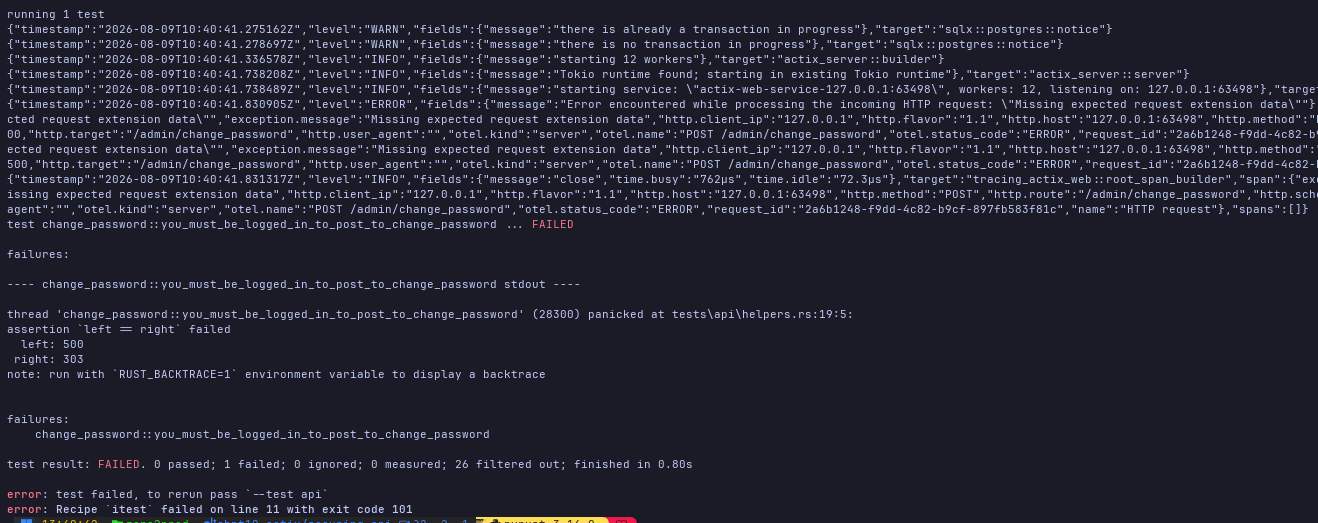

Lets inspect the logs to understand whats happening.

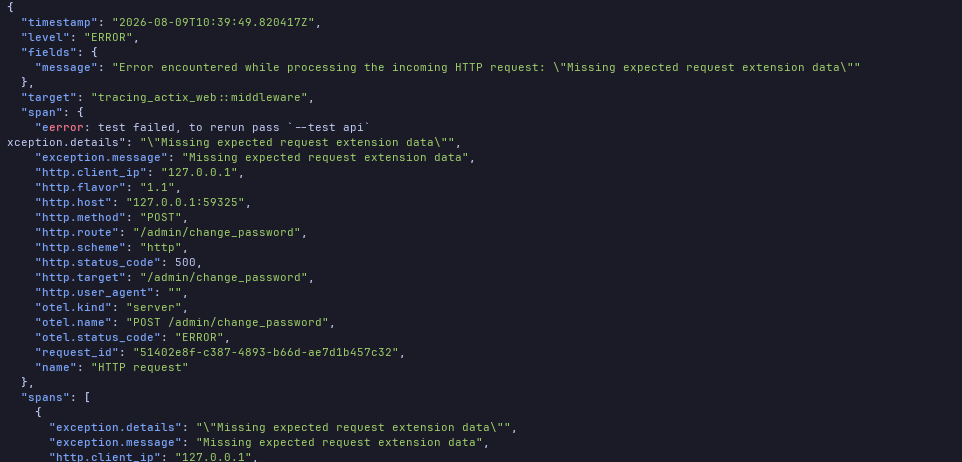

This is expected because we've not wired up our middleware for use in the routes. Lets fix that

**5. Update all routes to `/admin` to use the`reject_anonymous` middleware, using `actix_web::middleware`**
```Rust
// src/startup.rs
// [...]
use crate::authentication::middleware::reject_anonymous_users;

// [...]

async fn run(/**/) Result<Server, anyhow::Error> {
    // [...]
    let server = HttpServer::new(||{
        App::new()
            .wrap(/**/)
            //[...]
            .routes(/**/)
            .service(
                
                web::scope("/admin")
                    .wrap(actix_web::middleware::from_fn(reject_anonymous_users))
                    .routes("/dashboard", web::get().to(admin_dashboard))
                    .routes("/change_password", web::get().to(change_password))
                    .routes("/change_password", web::post().to(change_password))
                    .routes("/logout", web::post().to(logout))
            )
            .app_data(/**/)
            // [...]
    })
}
```

## 10.10. Summary.

##### 10.10.0.0. Skimming: What did you notice and why? Any Questions

_**What?**_  
- Cool set of challenges.

_**Why?**_  
- Hope by the end of the chapter I'm confident to tackle them head on without reference. Will let you know.

_**Question?**_  
None

##### 10.10.0.0.1. Deep Dive: Summarize, ELI5, Connect

To remember when deploying

1. Runs `cargo sqlx prepare`
2. Remember to perform migrations the the remote DB.

_**Summary**_  
So the book is kind enough to layout the steps in a similar fashion to how we've been working through the content.
> For the sake of clarity I've updated the endpoint name to `/admin/publish_newsletter` which in our context means  
> create newsletter issue + send newsletter issue

**Port `POST /newsletters` to session-based authentication `POST /admin/publish_newsletter`**  
  1. Add `send a newsletter issue` link to admin dashboard.
  2. Add a HTML form at `GET /admin/publish_newsletter_form` to submit a new issue;
  3. Adapt `POST /admin/publish_newsletter` to process the form data
        1. Change the route to `POST /admin/publish_newsletter`
        2. Migrate from 'Basic' to session-based authentication.
        3. Use the `Form` extractor (`application/x-www-form-urlencoded`) instead of the `Json` extractor (`application/json`)
              to handle the request body
        4. Adapt the test suite.


Lets get to it.  
Lets add `src/routes/newsletter/{{mod,get,post}.rs,newsletter.html}`, where most of our implementation will sit.

Also after evaulating our [current](https://github.com/SamNgigi/zero_to_production/blob/1e410b8df2855f4a366855fecdb484444711c338/zero2prod/tests/api/newsletter.rs) tests for newsetters we see that we are testing the endpoint against `Basic` Authentication.  
Following TDD and the fact that we are now porting the implementation to session-based authentication, we can start
our work by refactoring/adapting our tests.

Ideally our `tests/newsletters.rs` should look very similar to `tests/change_password.rs`, with the following tests to drive our implementation.

1. `you_must_be_logged_in_access_newsletter_form`
2. `you_must_be_logged_in_to_post_to_newsletter`
3. Adapting the following tests to be gated by authentication
   - `newsletters_are_not_delivered_to_unconfirmed_subscribers`
   - `newsletters_are_delivered_to_confirmed_subscribers`
   - Might need to break down `newsletters_return_400_for_invalid_data`  test into
       - `error_flash_message_is_set_on_missing_newsletter_title`
       - `error_flash_message_is_set_on_missing_newsletter_body` 
4. Add a `publish_newsletter_works` test.

This allows us to remove our 'Basic' authentication tests.
- `invalid_password_is_rejected_nl`
- `non_existent_user_is_rejected_nl`
- `requests_missing_authorization_are_rejected`.

We can start by removing the above tests and 

**1. Add `you_must_be_logged_in_to_access_newsletter_form`**.
> Here we need to add a `get_newletter_form` test helper.
```Rust
// tests/helpers.rs
// [...]

// [...]

impl TestApp {
    pub async fn get_newsletter_form(&self) -> reqwest::Response {
        self.client
            .get(format!("{}/admin/publish_newsletter", &self.address))
            .send()
            .await
            .except("Failed to execute GET /admin/newsletters request in test.")
    }
}
```

And then the test itself
```Rust
// tests/newsletter.rs
// [...]

async fn you_must_be_logged_in_to_access_publish_newsletter_form() {
    // Arrange
    let app = spawn_app().await;

    // Act
    let response = app.get_publish_newsletter_form().await;

    // Assert
    assert_on_redirect(&response, "/login");
}
```

This test does not fail, as we'd expect. Why?  
Lets inspect the logs.

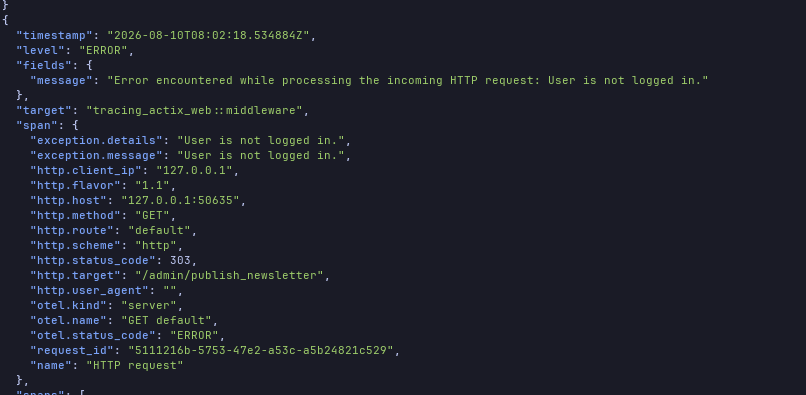

Rremember we have "protected" all `/admin` routes from anonymous users using our custom `reject_anonymous_users` middleware. Therefore  
the request doesn't event get to reach `GET /admin/publish_newsletter` endpoint to be processed. Neat.

That means that a test on `you_must_be_logged_in_to_post_to_publish_newsletter` will work as well.

**2. Add `you_must_be_logged_in_to_post_to_publish_newsletter` test**
> We already have the `post_newletters` helper. We just need to adapt it to use a form and remove the basic auth from the request.
```Rust
// tests/helpers.rs
// [...]

// [...]

impl TestApp {
    pub async fn post_publish_newsletter<Body>(&self, body: &Body) -> reqwest::Response
    where
        Body: serde::Serialize,
    {
        self.client
            .post(format!("{}/admin/publish_newsletter", &self.address))
            .form(body)
            .send()
            .await
            .expect("Failed to execute POST /admin/publish_newsletter request in test.")
    }
    // [...]
}
```

We haven't yet removed the original `post_newsletters` test helper. We'll remove it in a few. Lets go on implement the  actual
`you_must_be_logged_in_to_post_to_publish_newsletter` test.
```Rust
// tests/newsletters.rs
// [...]

#[tokio::test]
async fn you_must_be_logged_in_to_post_to_publish_newsletter() {
    // NOTE: Arrange
    let app = spawn_app().await;

    // NOTE: Act
    let response = app
        .post_publish_newsletter(&serde_json::json!({
            "title": "Newsletter title",
            "content": {
                "plain": "Newsletter as plain text",
                "html": "<p>Newsletter as HTML</p>",
            }
        }))
        .await;

    dbg!(&response);

    // NOTE: Assert
    assert_on_redirect(&response, "/login");
}
```

The test does not pass though.

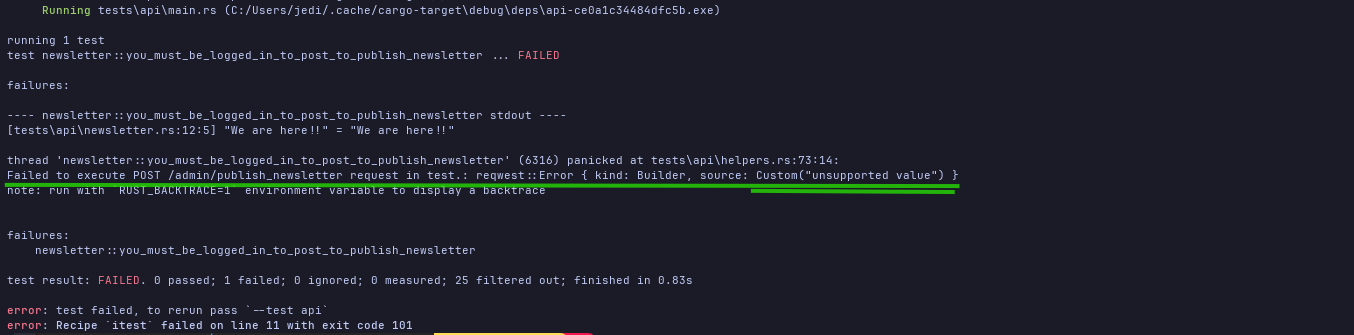

The problem is with the `post_publish_newsletter` helper. 
```Rust

impl TestApp {
    pub async fn post_publish_newsletter<Body>(&self, body: &Body) -> reqwest::Response
    where
        Body: serde::Serialize,
    {
            // [...]
            .post(format!("{}/admin/publish_newsletter", &self.address))
            .form(body) // <--  HERE
            // [...]
    }
}
```

A quick google reveals the issue.

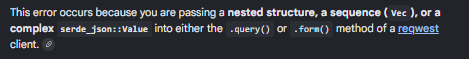



We want to update the endpoint to use the `web::Form` extractor. Currently though we are testing the endpoint using nested json. Lets
revert to json for now. 

```Rust
// tests/helpers.rs
// [...]

// [...]

impl TestApp {
    pub async fn post_publish_newsletter<Body>(&self, body: &Body) -> reqwest::Response
    where
        Body: serde::Serialize,
    {
        self.client
            .post(format!("{}/admin/publish_newsletter", &self.address))
            .json(body)
            .send()
            .await
            .expect("Failed to execute POST /admin/publish_newsletter request in test.")
    }

    // [...]
}

```

Our `you_must_be_logged_in_to_post_to_publish_newsletter` test passes due to our custom middleware.

Ok we are now at;
> 3. Adapting the following tests to be gated by authentication
>  - `newsletters_are_not_delivered_to_unconfirmed_subscribers`
>  - `newsletters_are_delivered_to_confirmed_subscribers`
>  - Might need to break down `newsletters_return_400_for_invalid_data`  test into
>      - `error_flash_message_is_set_on_missing_newsletter_title`
>      - `error_flash_message_is_set_on_missing_newsletter_body` 

To adapt/port the above tests successfully we have to
- Add a successful login assertions
- Update them to use our new `post_publish_newsletter` test helper.

Lets start with the `newsletters_are_not_delivered_to_unconfirmed_subscribers` test.
```Rust
#[tokio::test]
async fn newsletters_are_not_delivered_to_unconfirmed_subscribers() {
    // NOTE: Arrange
    let app = spawn_app().await;

    // NOTE: Act & Assert 1 - Succesful Login
    let login_request = serde_json::json!({
        "username": app.test_user.username,
        "password": app.test_user.password,
    });
    let response = app.post_login(&login_request).await;
    assert_on_redirect(&response, "/admin/dashboard");
    let admin_dashboard_html = app.get_admin_dashboard_html().await;
    assert!(admin_dashboard_html.contains(&format!("<p>Welcome {}.</p>", app.test_user.username)));

    // NOTE: Act & Assert 2 - Newsletters are not delivered to unconfirmed subs
    create_unconfirmed_subscriber(&app).await;

    Mock::given(any())
        .respond_with(ResponseTemplate::new(200))
        .expect(0)
        .mount(&app.email_server)
        .await;

    let newsletter_request_body = serde_json::json!({
        "title": "Newsletter title.",
        "content": {
            "plain": "Newsletter body as plain text",
            "html": "<p>Newsletter body as HTML</p>"
        }
    });

    let response = app.post_publish_newsletter(&newsletter_request_body).await;
    assert_eq!(response.status().as_u16(), 200);
}

```

Now our test fails.

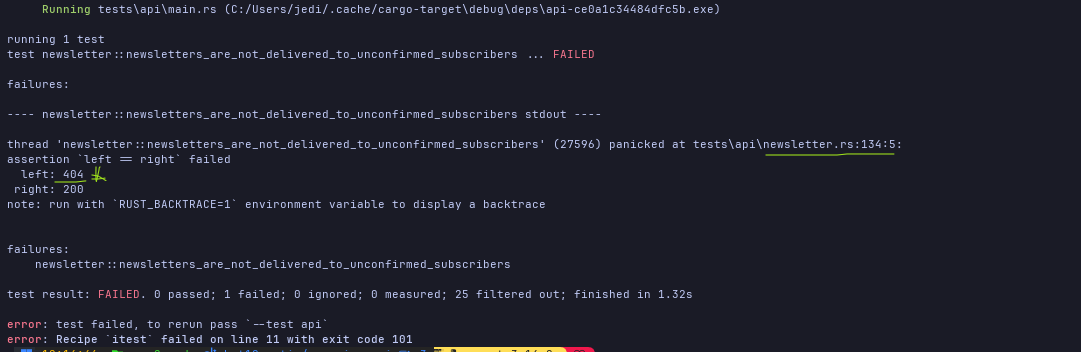

And this is what we expected because we don't have the `GET /admin/publish_newsletter` end point.  
Its seems the successful login assertions worked though. We can move with confidence knowing that the end point is appropriately gated.  

To get this test to pass is straignt foward enough. We just need to update the endpoint in `startup.rs`

```Rust
// src/startup.rs
// [...]

// [...]

async fn run(/**/) -> Result<Server, anyhow::Error> {
    // [...]
    let server = HttpServer::new(move || {
        App::new()
            .wrap(flash_messages.clone())
            .wrap(SessionMiddleware::new(
                session_store.clone(),
                secret_key.clone(),
            ))
            .wrap(TracingLogger::default())
            .route("/health_check", web::get().to(health_check))
            .route("/", web::get().to(greet))
            .route("/home", web::get().to(home))
            .route("/login", web::get().to(login_form))
            .route("/login", web::post().to(login))
            .route("/{name}", web::get().to(greet))
            .service(
                web::scope("/admin")
                    .wrap(actix_web::middleware::from_fn(reject_anonymous_users))
                    .route("/dashboard", web::get().to(admin_dashboard))
                    .route("/change_password", web::get().to(change_password_form))
                    .route("/change_password", web::post().to(change_password))
                    // We add tne route to the "admin" scope:w
                    .route("/publish_newsletter", web::post().to(publish_newsletter))
                    .route("/logout", web::post().to(logout)),
            )
            .route("/subscriptions", web::post().to(subscribe))
            // We remove the `/newsletter` rounte
            // [...]    
    })
    .listen(listener)?
    .run();

    Ok(server)
}
```

Do our tests pass. Nope. We get another issue.

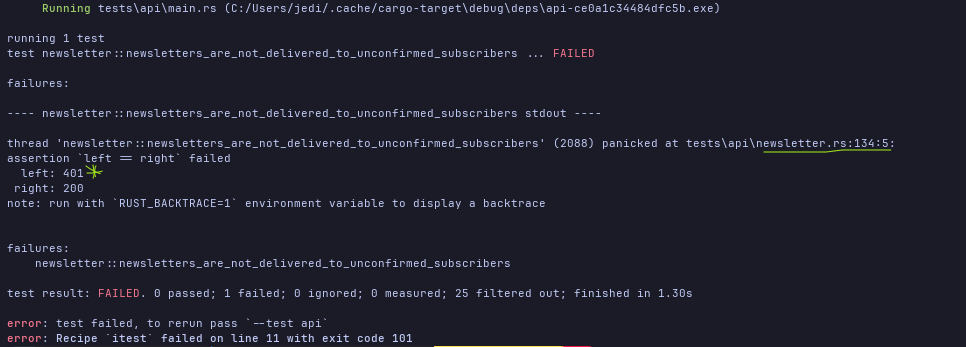

We are getting a 401 (UnAuthorized request). What? Why? Lets do a `dbg!(&response)` in our test to see what the issue is.

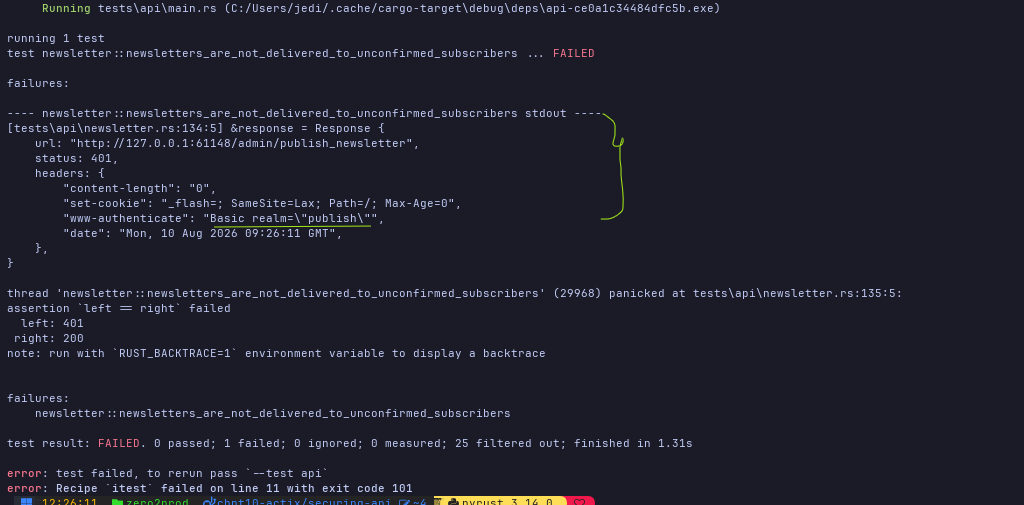

Yup our [`publish_newsletter`](https://github.com/SamNgigi/zero_to_production/blob/40f754cb3326a0a4f721b4584c6a350255f43c3d/zero2prod/src/routes/admin/newsletter/post.rs) handler is still implementing 'Basic' authentication and inspecting the headers. Time to update the handler.

We can effectively remove all the `basic_authentication` and `validate_credentials` logic. What if we still want to trace the `username` and `user_id`?
For the `user_id` this is straight forward becase we already have it as part of the session. For the `username` we have a few options. The most straightforward;
- Use the `get_username` function that retrievs the username from the db,
- Insert `username` into the session during login.

Let's leave that for later. Tracing using the `user_id` should be enough for now. Our `publish_newsletter` handler should now look like this.
> Make sure to remove all unused imports.
```Rust
// src/routes/admin/newsletter/post.rs
// [...]
use crate::authentication::UserId;

#[tracing::instrument(
    name = "Publish Newsletter.",
    skip(db_pool, email_client, body),
    fields(
        user_id = tracing::field::Empty,
    )
)]
pub async fn publish_newsletter(
    db_pool: web::Data<PgPool>,
    email_client: web::Data<EmailClient>,
    body: web::Json<BodyData>,
    // We revmoe the request parameter
    user_id: web::ReqData<UserId>, // New Param
) -> Result<HttpResponse, PublishError> {

    // We now use the `user_id` that we retrieve from the session.
    tracing::Span::current().record("user_id", tracing::field::display(*user_id.into_inner()));

    let subscribers = get_confirmed_subscribers(&db_pool).await?;

    // [...]
}

// We remove the `basic_authentication` function.

struct ConfirmedSubscriber {
    email: SubscriberEmail,
}

// [...]

```

Is this enough to make our test pass? Yup. Our test passes.

Refactoring the `newsletters_are_delivered_to_confirmed_subscribers` test is straigh foward as wall
- Adding the successful login assertion
- Updating to using our new `post_publish_newsletter` test helper.

This time our test should pass without needing to update anything else.

Alright what about the `newsletters_return_400_for_invalid_data` test. This one might be a bit involved. 
As we mentioned earlier, we might want to break it down into two tests, so that we can render a flash error message when we have
- A missing title
- Missing body/content.

Also thinking a little more about how we want to implement the form for `publish_newsletter_form`, we might just want 2 fields
- A title field
- A content field.

The we let the backend generated a the html version if necessary. Here we can leverage `pulldown-cmark` and `ammonia` crates for markdwon to 
html conversion.

Lets write the tests 
> Lets update our `post_publish_newsletter` test helper to take 2 fields (title, content) as opposed to the nested content. We'll have a string content.
```Rust
// tests/helper.rs
// [...]

// [...]

impl TestApp {
    pub async fn post_publish_newsletter<Body>(&self, body: &Body) -> reqwest::Response
    where
        Body: serde::Serialize,
    {
            // [...]
            .post(format!("{}/admin/publish_newsletter", &self.address))
            .form(body) // <--  HERE
            // [...]
    }
    // [...]
}
```

We'll need to update the tests that were making using of the nested `content` field.

We also need a `get_publish_newsletter_html()` test helper for asserting that our flash error message was rendered.

```Rust
// tests/helper.rs
// [...]

// [...]

impl TestApp {
    pub async fn get_publish_newsletter_html() -> String {
        self.get_publish_newsletter()
            .await
            .text()
            .await
            .expect("Failed to decode HTML to valid text.")
    }
    // [...]
}
```

Lets go ahead and ;
**Add the `error_flash_message_is_set_when_a_newsletter_issue_is_missing_a_title**
```Rust
// tests/newsletter.rs
// [...]

#[tokio::test]
async fn error_flash_message_is_set_on_missing_title_for_newsletter_issue() {
    // NOTE: Arrange
    let app = spawn_app().await;

    // NOTE: Act + Assert 1 - Succesful login
    let login_request = serde_json::json!({
        "username": app.test_user.username,
        "password": app.test_user.password,
    });
    let response = app.post_login(&login_request).await;
    assert_on_redirect(&response, "/admin/dashboard");
    let admin_dashboard_html = app.get_admin_dashboard_html().await;
    assert!(admin_dashboard_html.contains(&format!("<p>Welcome {}.</p>", app.test_user.username)));

    // NOTE: Act + Assert 2 - Redirect to GET /admin/publish_newsletter on missing title
    let response = app
        .post_publish_newsletter(&serde_json::json!({
            "content": "Newsletter content"
        }))
        .await;
    assert_on_redirect(&response, "/admin/publish_newsletter");

    // NOTE: Act + Assert 3 - Flash Error message is rendered
    let publish_newsletter_html = app.get_publish_newsletter_html().await;
    assert!(publish_newsletter_html.contains(r#"<p><i>Newsletter is missing a title.</i></p>"#));
}
```

The test should fail.

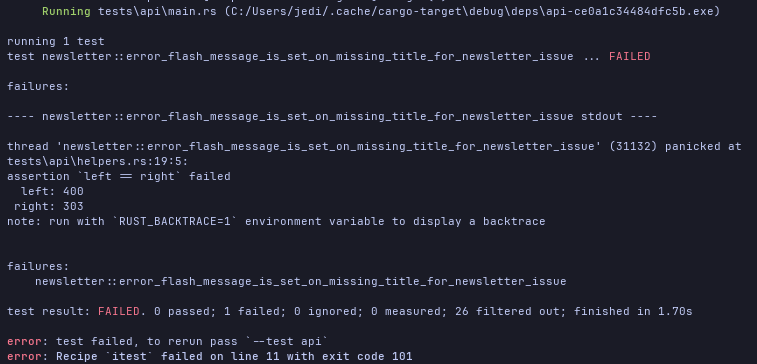

To make the test pass, we have to refactor our `publish_newsletter` handler again.   
Now we need to port the implementation from using the `Json` extractor to `Form` extractor. Because `Form` doesn't allow nesting, we  
also refactor from using a `Content` type that held both `html` & `plain` text. Our `FormData` will now just hold a title & content string.

But what about differentiating between `HthmlBody` and `TextBody` required by postmark.  
We'll lean on 2 `pulldown-cmark` and `ammonia` crates to convert the content string to html format that we'll use to populate the `HtmlBody`.

After updating the handler our final code should looks similar to this
```Rust
// src/routes/admin/newsletter/post.rs
// [...]
use actix_web_flash_messages::FlashMessage;
    
use crate:: authentication::UserId;

// [...]

// We remove BodyData and Content & replace with FormData.
#[derive(serde::Deserialize)]
pub struct FormData {
    title: String,
    txt_content: String,
}

#[tracing::instrument(
    name = "Publish Newsletter.",
    skip(db_pool, email_client, form),
    fields(
        user_id = tracing::field::Empty,
    )
)]
pub async fn publish_newsletter(
    db_pool: web::Data<PgPool>,
    email_client: web::Data<EmailClient>,
    form: web::Form<FormData>,
    user_id: web::ReqData<UserId>,
) -> Result<HttpResponse, PublishError> {
    tracing::Span::current().record("user_id", tracing::field::display(*user_id.into_inner()));

    let subscribers = get_confirmed_subscribers(&db_pool).await?;

    if form.0.title.is_empty() {
        FlashMessage::error("Newsletter issue is missing a title. Issue must have a title.").send();
        return Ok(see_other("/admin/publish_newsletter"));
    }

    let html_content = get_html(&form.0.txt_content);

    for sub in subscribers {
        match sub {
            Ok(subscriber) => email_client
                .send_email(
                    &subscriber.email,
                    &form.0.title,
                    &html_content,
                    &form.0.txt_content,
                )
                .await
                .with_context(|| {
                    format!("Failed to send newsletter issue to {}", subscriber.email)
                })?,
            Err(error) => {
                tracing::warn!(
                    error.cause_chain = ?error,
                    "Skipping confirmed subscriber. \
                    Store contact details are invalid: {}",
                    error
                );
            }
        }
    }

    Ok(HttpResponse::Ok().finish())
}

fn get_html(text: &str) -> String {
    let parser = pulldown_cmark::Parser::new(text);
    let mut html_output = String::new();
    pulldown_cmark::html::push_html(&mut html_output, parser);
    ammonia::clean(&html_output)
}

// [...]
```

We've added a `get_html` helper function to get html from the content string.

Next we need to now implement the `publish_newsletter_form` handler and the `newsletter.html` to go with it.

```Rust
// src/routes/admin/newsletter/get.rs
// [...]

use actix_web::{HttpResponse, http::header::ContentType};
use actix_web_flash_messages::IncomingFlashMessages;
use std::fmt::Write;

pub async fn publish_newsletter_form(flash_messages: IncomingFlashMessages) -> HttpResponse {
    let mut msg_html = String::new();
    for msg in flash_messages.iter() {
        writeln!(msg_html, "<p><i>{}</i></p>", msg.content())
            .expect("Failed to write flash message content to msg_html");
    }
    HttpResponse::Ok()
        .content_type(ContentType::html())
        .body(format!(
            include_str!("./newsletter.html"),
            msg_html = msg_html
        ))
}
```
```HTML
<!--src/routes/admin/newsletter/newsletter.html-->
<!DOCTYPE html>
<html lang="en">
<head>
  <meta http-equiv="content-type" content-type="text/html" charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Newsletter Form</title>
</head>
<body>
  <h4>Publish Newsletter Issue</h4>
  {msg_html}
  <form action="/admin/publish_newsletter" method="POST">
    <label for="title">Title:</label>
    <input type="text" placeholder="Newsletter Title" id="title">

    <label for="newsletter_content">Content:</label>
    <textarea 
      name="txt_content" 
      id="newsletter_content"
      row= "4"
      cols = "50"
      placeholder="Type newsletter content here in markdown format."
      >
    </textarea>

    <button type="submit">Publish</button>
  </form>
</body>
</html>
```

With this our test should pass.

Implementing the `error_flash_message_is_set_on_missing_content_for_newsletter_issue` is very straight forward.
```Rust
// tests/newsletter.rs

#[todkio::test]
async fn error_flash_message_is_set_on_missing_content_for_newsletter_issue() {
    // NOTE: Arrange
    let app = spawn_app().await;

    // NOTE: Act + Assert 1 - Succesful login
    let login_request = serde_json::json!({
        "username": app.test_user.username,
        "password": app.test_user.password,
    });
    let response = app.post_login(&login_request).await;
    assert_on_redirect(&response, "/admin/dashboard");
    let admin_dashboard_html = app.get_admin_dashboard_html().await;
    assert!(admin_dashboard_html.contains(&format!("<p>Welcome {}.</p>", app.test_user.username)));

    // NOTE: Act + Assert 2 - Redirect to GET /admin/publish_newsletter on missing content
    let response = app
        .post_publish_newsletter(&serde_json::json!({
            "title": "Newsletter title",
            "txt_content": ""
        }))
        .await;
    assert_on_redirect(&response, "/admin/publish_newsletter");

    // NOTE: Act + Assert 3 - Flash Error message is rendered
    let publish_newsletter_html = app.get_publish_newsletter_html().await;
    assert!(publish_newsletter_html.contains(
        r#"<p><i>Newsletter issue is missing content. Issue must have a content.</i></p>"#
    )); 
}
```

The test should fail.

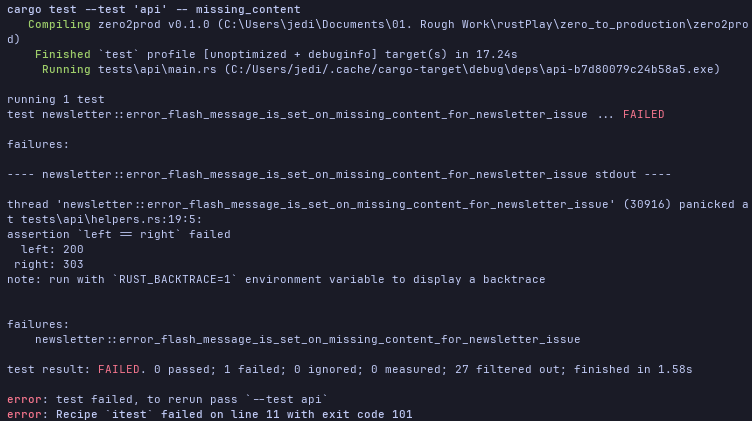

Now to make the test pass.
```Rust
// src/routes/admin/newsletter/post.rs
// [...]

// [...]

pub async fn publish_newsletter(/**/) -> Result</**/> {
    // [...]
    
   if form.0.txt_content.is_empty() {
        FlashMessage::error("Newsletter issue is missing content. Issue must have a content.")
            .send();
        return Ok(see_other("/admin/publish_newsletter"));
    }
 
    // [...]
}

```

With that our test should pass.

Finally we can add a `publish_newsletter_works_test`
```Rust
// tests/api/newsletter.rs
// [...]

#[tokio::test]
async fn publish_newsletter_works() {
    // NOTE: Arrange
    let app = spawn_app().await;

    // NOTE: Act + Assert 1 - Successful login
    let login_request = serde_json::json!({
        "username": app.test_user.username,
        "password": app.test_user.password,
    });
    let response = app.post_login(&login_request).await;
    assert_on_redirect(&response, "/admin/dashboard");
    let admin_dashboard_html = app.get_admin_dashboard_html().await;
    assert!(admin_dashboard_html.contains(&format!("<p>Welcome {}.</p>", app.test_user.username)));

    // NOTE: Act + Assert 2 - Redirect to GET /admin/publish_newsletter
    let response = app
        .post_publish_newsletter(&serde_json::json!({
            "title": "Newsletter title",
            "txt_content": "Newsletter content."
        }))
        .await;
    assert_on_redirect(&response, "/admin/publish_newsletter");

    // NOTE: Act + Assert 3 - Publish newsletter successful flash message is rendered
    let publish_newsletter_html = app.get_publish_newsletter_html().await;
    assert!(
        publish_newsletter_html
            .contains(r#"<p><i>Newsletter Issue Published Successfully.</i></p>"#)
    );
}

```


Test should fail.

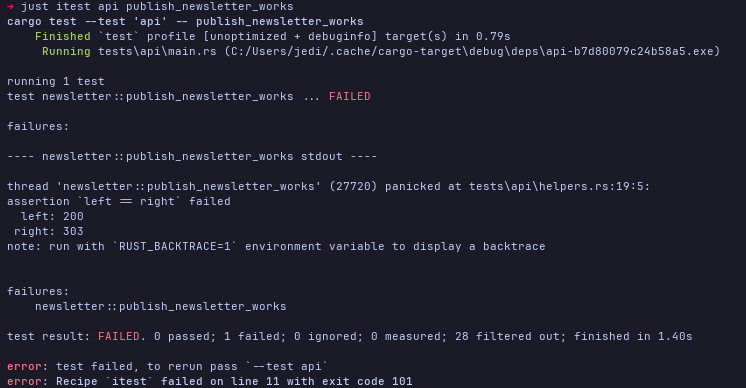

Currently when everything goes according to plan we are just returning a `200 OK`

To get this test to pass, we just need to redirect to `GET /admin/publish_newsletter` with an info flash message communicating that the publish was successful.
```Rust
// src/routes/admin/newsletter/post.rs
// [...]

// [...]

pub async fn publish_newsletter(/**/) -> Result</**/> {
    // [...]
    
    FlashMessage::info("Newsletter Issue Published Successfully.").send();
    Ok(see_other("/admin/publish_newsletter"))
}
```

Our test pass. Now all that is left is remove the legacy `post_newsletter` test helper and `newsletters_return_400_for_invalid_data` test, then  
run all the tests.
> `newsletters_are_not_delivered_to_unconfirmed_subscribers` and `newsletters_are_delivered_to_confirmed_subscribers` tests might fail. Remember to adapt them
> to take in form data instead of the original nested json and assert a redirect $303$ status code instead of $200$ status code.


## 10.x. Axum implementation

### 10.x.0. Overview

Our axum implementation is going to be more succinct because we are implementing our final iteration, without going through the many learning  
that we've already covered quite in depth.

So what sections do we need to implementen?  
We will start from the Login implementation and basically ignore everything before it around Password-based Authentication.  
We can come back to it for the sake of learning after we've finished the book, but we don't gain much from re-implementing  
those earlier section in `axum`.

Maybe the only exception are 
- Password-based authentication
    - Password Verification
    - Password Storage
    - Not blocking the Async executor
    - User enumeration

But re-ordered to start from the Login workflows. So what will our implementation order look like? Here's what i'm thinking
1. Login: Add `tests/login.rs` module.
    1. Add `an_error_flash_message_is_set_on_failure` test. (This will require us to set up sesions)
        1. Add `post_login` test helper & `get_login_html` test helper.
        2. Create `users` table with `user_id`, `username` and `password_hash` columns.
        3. Add login module
            1. Implement initial `login_form` and `login` handler sketelons
            2. Flesh out `login` handler
                1. Add authentication module
                    1. Implement `validate_credentials`
                        1. Implement `AuthError`
                    3. Implement `get_stored_credentials` 
                    4. Implement `verify_password_hash` 
                3. Add `actix_messages` & `tower_sessions-cookie_store` for cookie based [flash messages](https://share.google/aimode/rwyMYTQGTFondimLP).
                4. Add `utils.rs` module with a `see_other` util function.
                5. Add `redirect_to_login` helper
            3. Flesh out `login_form` handler
                1. Add `login.html`
                2. Pull our error flash messages and render them to the html
    2. Add `redirects_to_admin_dashboard_on_successful_login` test
        1. Add `get_admin_dashboard_html` test helper.
        2. Add `tower-sessions` and insert `user_id` in `login` handler on successful `validate_credentials`  
            1. Redirect to admin dashboard. Use `see_other` for the redirect
            2. Add `src/routes/admin` moodule
                1. Flesh out  `admin_dashboard.html` and `admin_dashboard` handler.
                    1. Implement `e500` util for opaque error handlling if `user_id` not in session
                    2. Implement `get_username` and render returned `username` in `admin_dashboard.html`
        3. Add custom `TypedSession`  using `tower-session` and make it an custom axum extractor using `FromRequestParts`
        4. Implement `authentication/middleware.rs` using `axum::middleware`
    3. Add `you_must_be_logged_in_to_access_admin_dashboard` test.
        1. Add  `get_admin_dashboard` and `get_admin_dashboard_html` test helpers.
        2. Update `admin_dashboard` handler to redirect to `login` if request is unauthorized/unauthenticated.
    4. Deploy to production
        1. Configure Redis. Refer to [this](https://claude.ai/share/28a3a9aa-b143-4f13-b7c1-28bdc4107457) claude conversation.
        2. Make sure to run `sqlx prepare` before deployment.
        3. Confirm live site working. 

From here, we'll go into 
- The Seed Users section with the password reset functionality and
- Gating `publish_newsletter` behind authentication
    - Updating the tests for session-based authentication.
    - Moving the implementation into a `routes/admin/newsletter.rs` module.
    - Adding the `newsletter.html` + `publish_newsletter_form` handler + updating the `publish_newsletter` handler.

We won't have to do the middleware because we are going to address that when working on the login functionality

For custom axum middleware 

```Rust
use axum::{
    Extension,
    http::{Request, StatusCode},
    middleware::{self, Next},
    response::Response,
    routing::get,
    Router,
};

#[derive(Clone, Debug)]
struct CurrentUser {
    id: u64,
}

async fn inject_user_middleware(
    mut request: Request<axum::body::Body>,
    next: Next,
) -> Result<Response, StatusCode> {
    let user = CurrentUser { id: 42 };
    
    // Attach custom data to the request lifecycle
    request.extensions_mut().insert(user);
    
    Ok(next.run(request).await)
}

// Handler reads the data using the Extension extractor
async fn profile_handler(Extension(user): Extension<CurrentUser>) -> String {
    format!("Welcome back user: {}", user.id)
}

```

And grouping multiple authenticated routes

```Rust
use axum::{middleware, routing::get, Router};

async fn dashboard() -> &'static str {
    "Welcome to the secret dashboard!"
}

async fn settings() -> &'static str {
    "User settings page"
}

async fn public_route() -> &'static str {
    "Anyone can see this."
}

#[tokio::main]
async fn main() {
    // Group multiple routes that need protection
    let protected_routes = Router::new()
        .route("/dashboard", get(dashboard))
        .route("/settings", get(settings))
        .route_layer(middleware::from_fn(auth_middleware));

    // Combine with public routes
    let app = Router::new()
        .route("/", get(public_route))
        .merge(protected_routes);

    let listener = tokio::net::TcpListener::bind("127.0.0.1:3000").await.unwrap();
    axum::serve(listener, app).await.unwrap();
}

```

### 10.x.1 Redis Setup

Setting up redis on fly.io in production

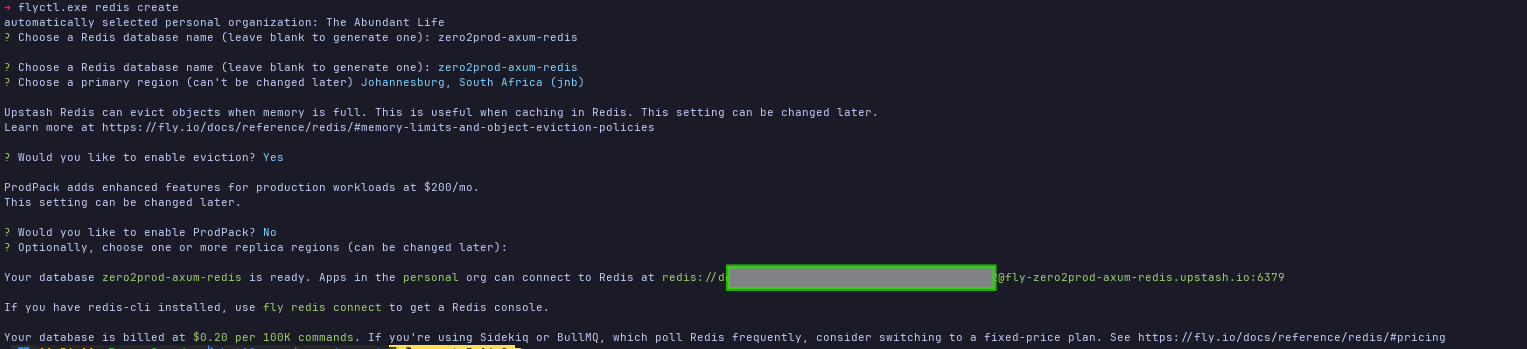

### 10.x.3 Axum specific Deviations

The axum implementation was roughly similar to the actix implementations except for 2-3 keys areas
1. Flash Messaging
2. Handling generic opaque internal server error
3. Serving HTML

Flash Messaging was probably the biggest deviation.  
While our actix implementation has 2 distinct stores
- Cookies for flash messages
- Redis for session storage

In axum we are working with only one store which is redis for both session storage and flash messages via the following
3 crates.
- `axum-messages`
- `tower-sessions`
- `tower-sessions-redis-store`

 Because we are storing our flash message as part of the session I opted for a `flash.rs` module that shapes our implementation.
 Specifically calling out the need for `FlashWriter` and `FlashReader` that a wrappers around `axum_messages::Messages` that allows
 us to work with `Messages` across multiple layers & sessions. 

 There are 2 implementations of our middlware that we experimented with. 
 - A [minimal version](https://github.com/SamNgigi/zero_to_production/blob/chpt10-axum/securing-api/zero2prod/src/authentication/middleware.rs) that and extracts `Messages` from the request in the middleware and uses a clone to insert error flash messages for auth gated routes 
 - A [version](https://github.com/SamNgigi/zero_to_production/blob/chpt10-axum/securing-api-flash-explore/zero2prod/src/authentication/middleware.rs) with `FlashWriter/FlashReader` that wraps `axum_messages::Messages`. This allows us to reuse the same flash logic for any future middleware
   rather than remembering to extract and clone a `Message` paramater in the middleware.

Without either of the above approaches, routes gated by the middleware were not rendering our flash messages do to `Messages::load` that is destructive and **not** idempotent that was being triggered twice.
- In the middleware
- In the handlers

This would clear the messages array before they get to the relevant handlers to be rendered.